## Stacked bar plots with svg

DIRECTIONAL EFFECT-SIZE PLOTS (STACKED BAR)

COMPARTMENT: Non-Immune (nonimmune)
  ✅ Loading: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_nonimmune/bayesian_results_3group_with_rope.csv
  Rows loaded: 57
  ✅ Filtered to 57 rows. Cells: ['Fibroblasts', 'Islet endocrine', 'Pericytes SMC', 'Schwann', 'Tumor classical', 'Tumor epithelial', 'iCAF']

  Creating stacked bar plots...
  ✅ Saved PNG: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_nonimmune/publication_figures/stacked_bar_plots/effectsize_updown_nonimmune.png
  ✅ Saved SVG: /content/drive/MyDrive/new_dysfunction/svg_images/stacked_bar_plots/nonimmune/effectsize_updown_nonimmune.svg


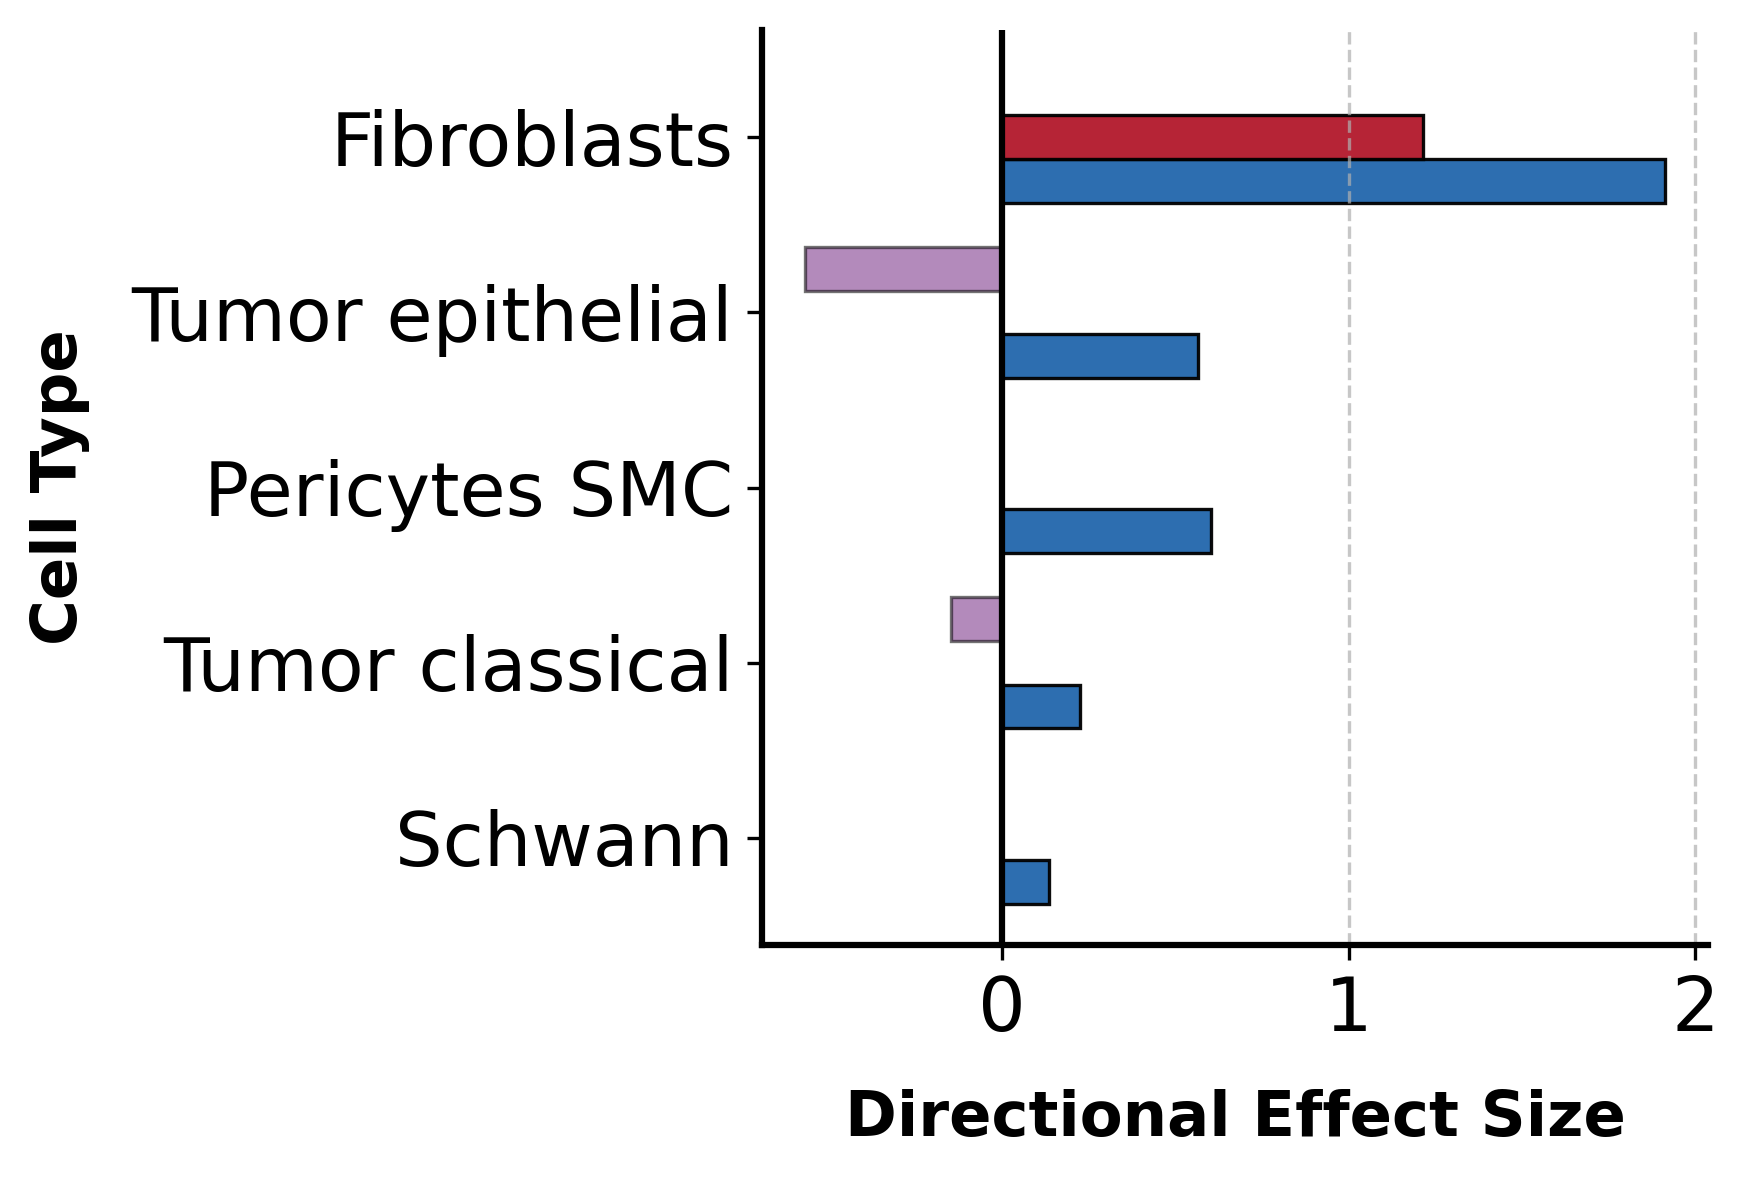

  ✅ Saved legend PNG: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_nonimmune/publication_figures/stacked_bar_plots/legend_effectsize_updown_nonimmune.png
  ✅ Saved legend SVG: /content/drive/MyDrive/new_dysfunction/svg_images/stacked_bar_plots/nonimmune/legend_effectsize_updown_nonimmune.svg


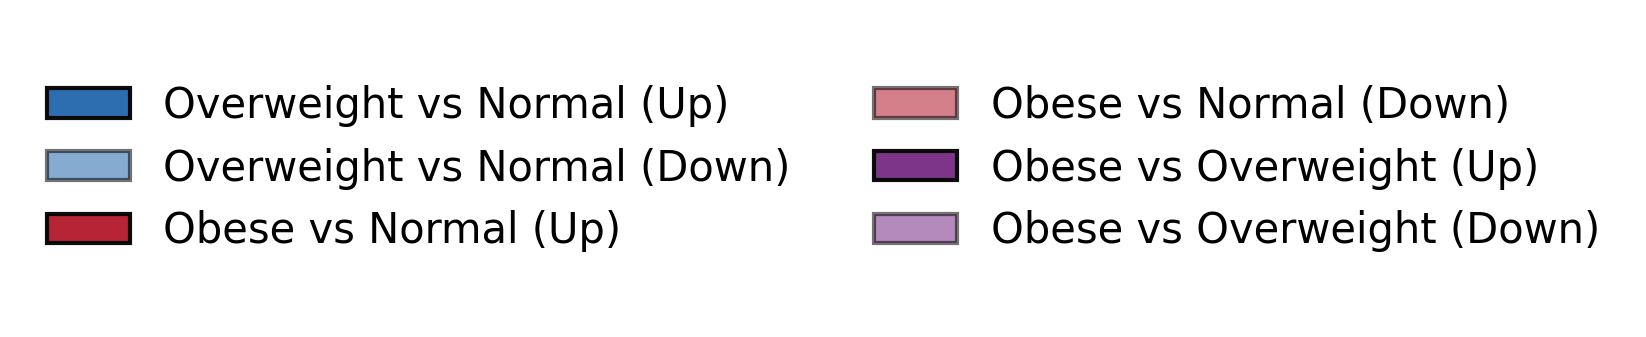


COMPARTMENT: Immune Fine (immune_fine)
  ✅ Loading: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_immune_fine/bayesian_results_3group_with_rope.csv
  Rows loaded: 48
  ✅ Filtered to 45 rows. Cells: ['B cells naive', 'CD4 T naive', 'CD8 Tmemory']

  Creating stacked bar plots...
    ℹ️  No credible effects for obese_vs_overweight
  ✅ Saved PNG: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_immune_fine/publication_figures/stacked_bar_plots/effectsize_updown_immune_fine.png
  ✅ Saved SVG: /content/drive/MyDrive/new_dysfunction/svg_images/stacked_bar_plots/immune_fine/effectsize_updown_immune_fine.svg


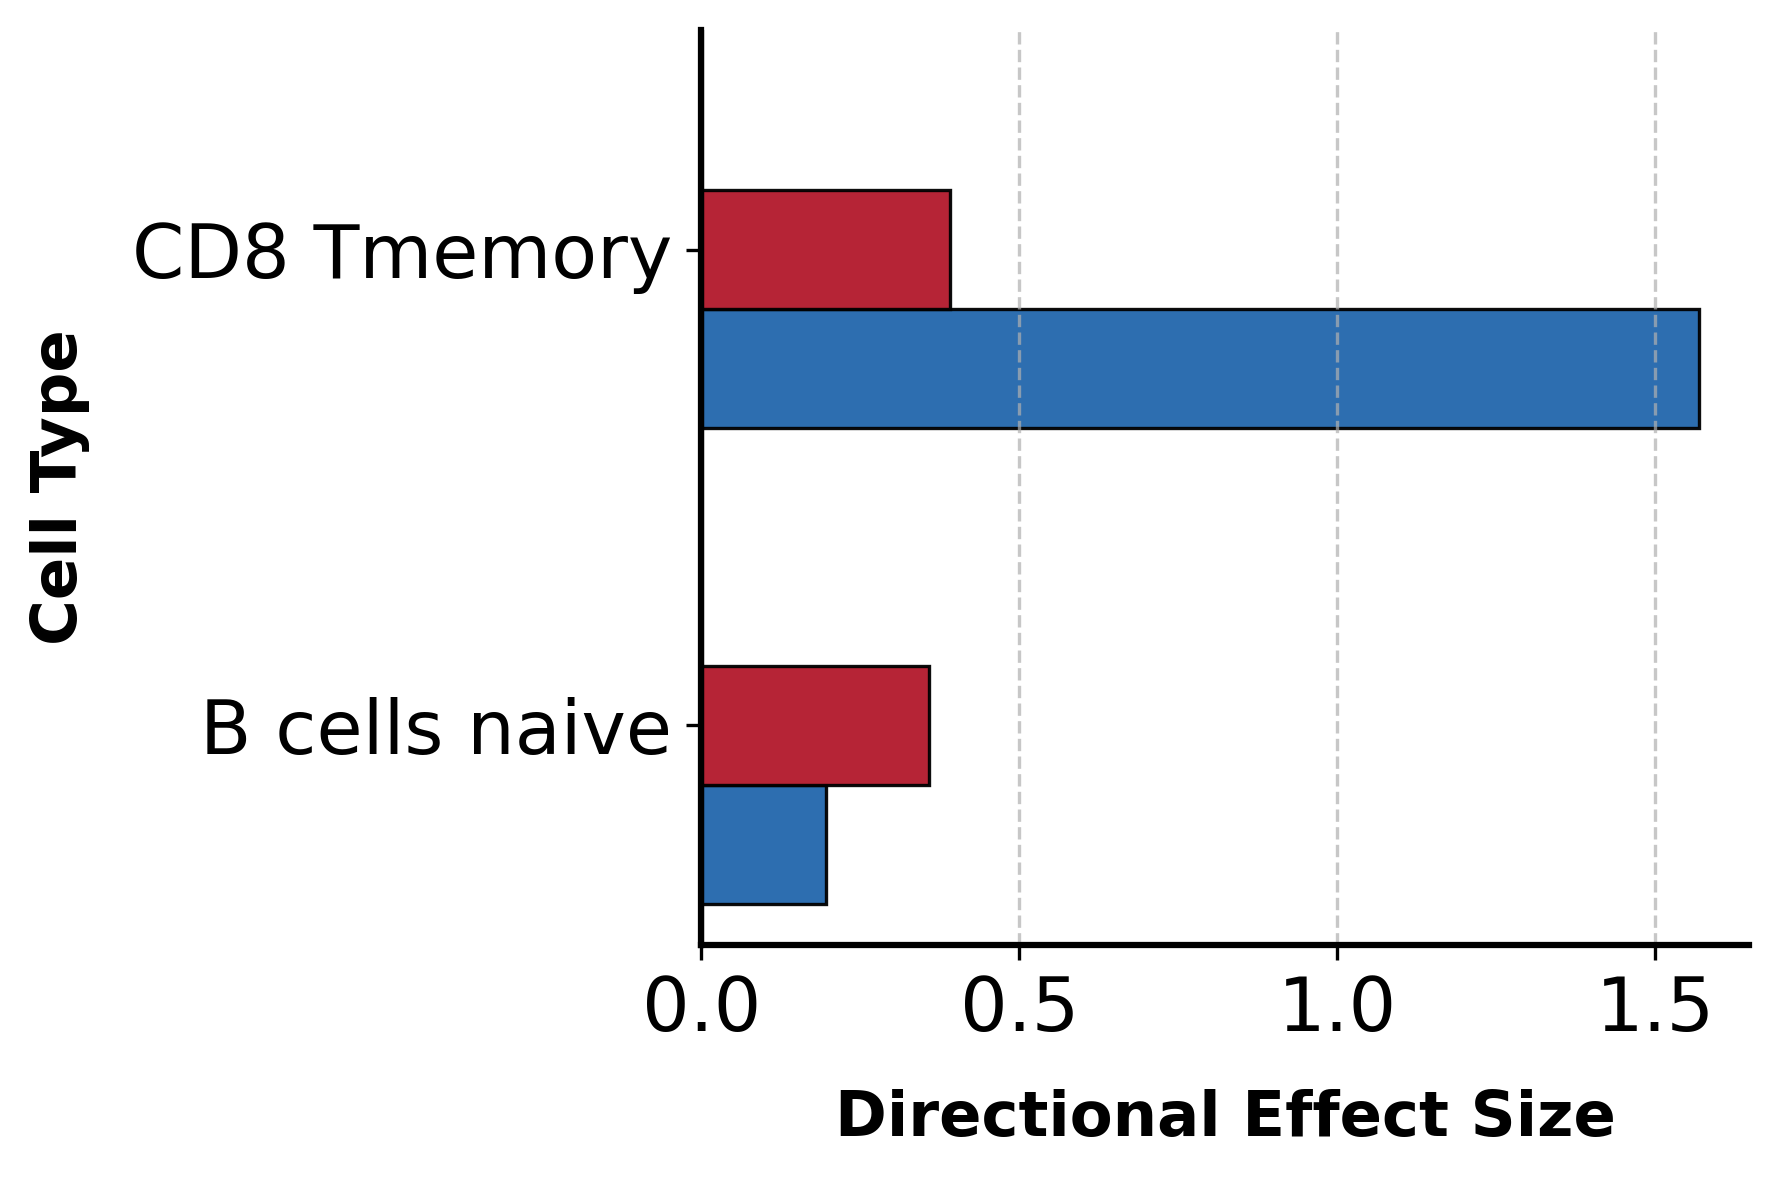

  ✅ Saved legend PNG: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_immune_fine/publication_figures/stacked_bar_plots/legend_effectsize_updown_immune_fine.png
  ✅ Saved legend SVG: /content/drive/MyDrive/new_dysfunction/svg_images/stacked_bar_plots/immune_fine/legend_effectsize_updown_immune_fine.svg


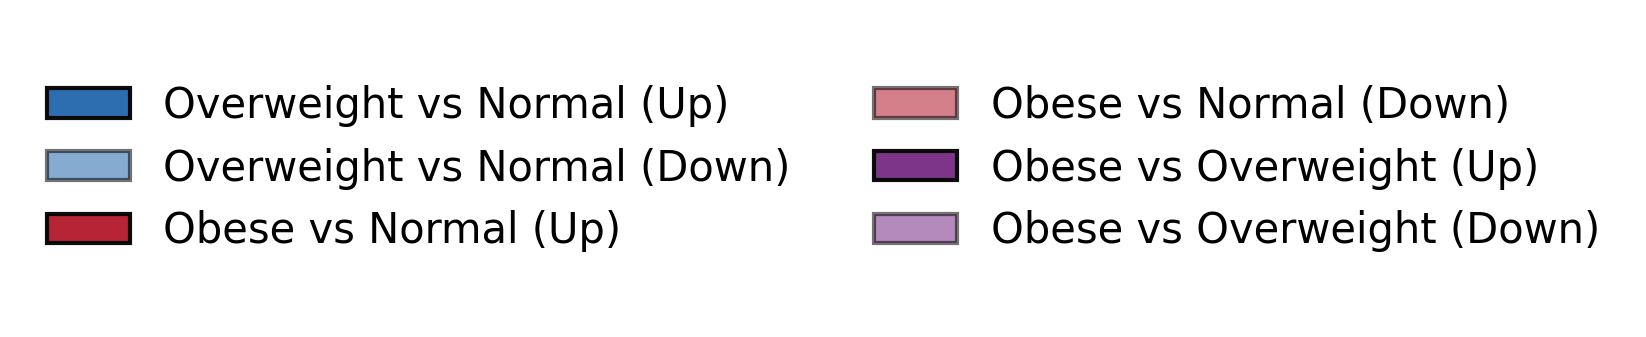


COMPARTMENT: Immune Coarse (immune_coarse)
  ✅ Loading: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_immune_coarse/bayesian_results_3group_with_rope.csv
  Rows loaded: 25
  ✅ Filtered to 25 rows. Cells: ['Basophils', 'Dendritic cells', 'Monocytes', 'NK cells', 'T cells']

  Creating stacked bar plots...
    ℹ️  No credible effects for obese
  ✅ Saved PNG: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_immune_coarse/publication_figures/stacked_bar_plots/effectsize_updown_immune_coarse.png
  ✅ Saved SVG: /content/drive/MyDrive/new_dysfunction/svg_images/stacked_bar_plots/immune_coarse/effectsize_updown_immune_coarse.svg


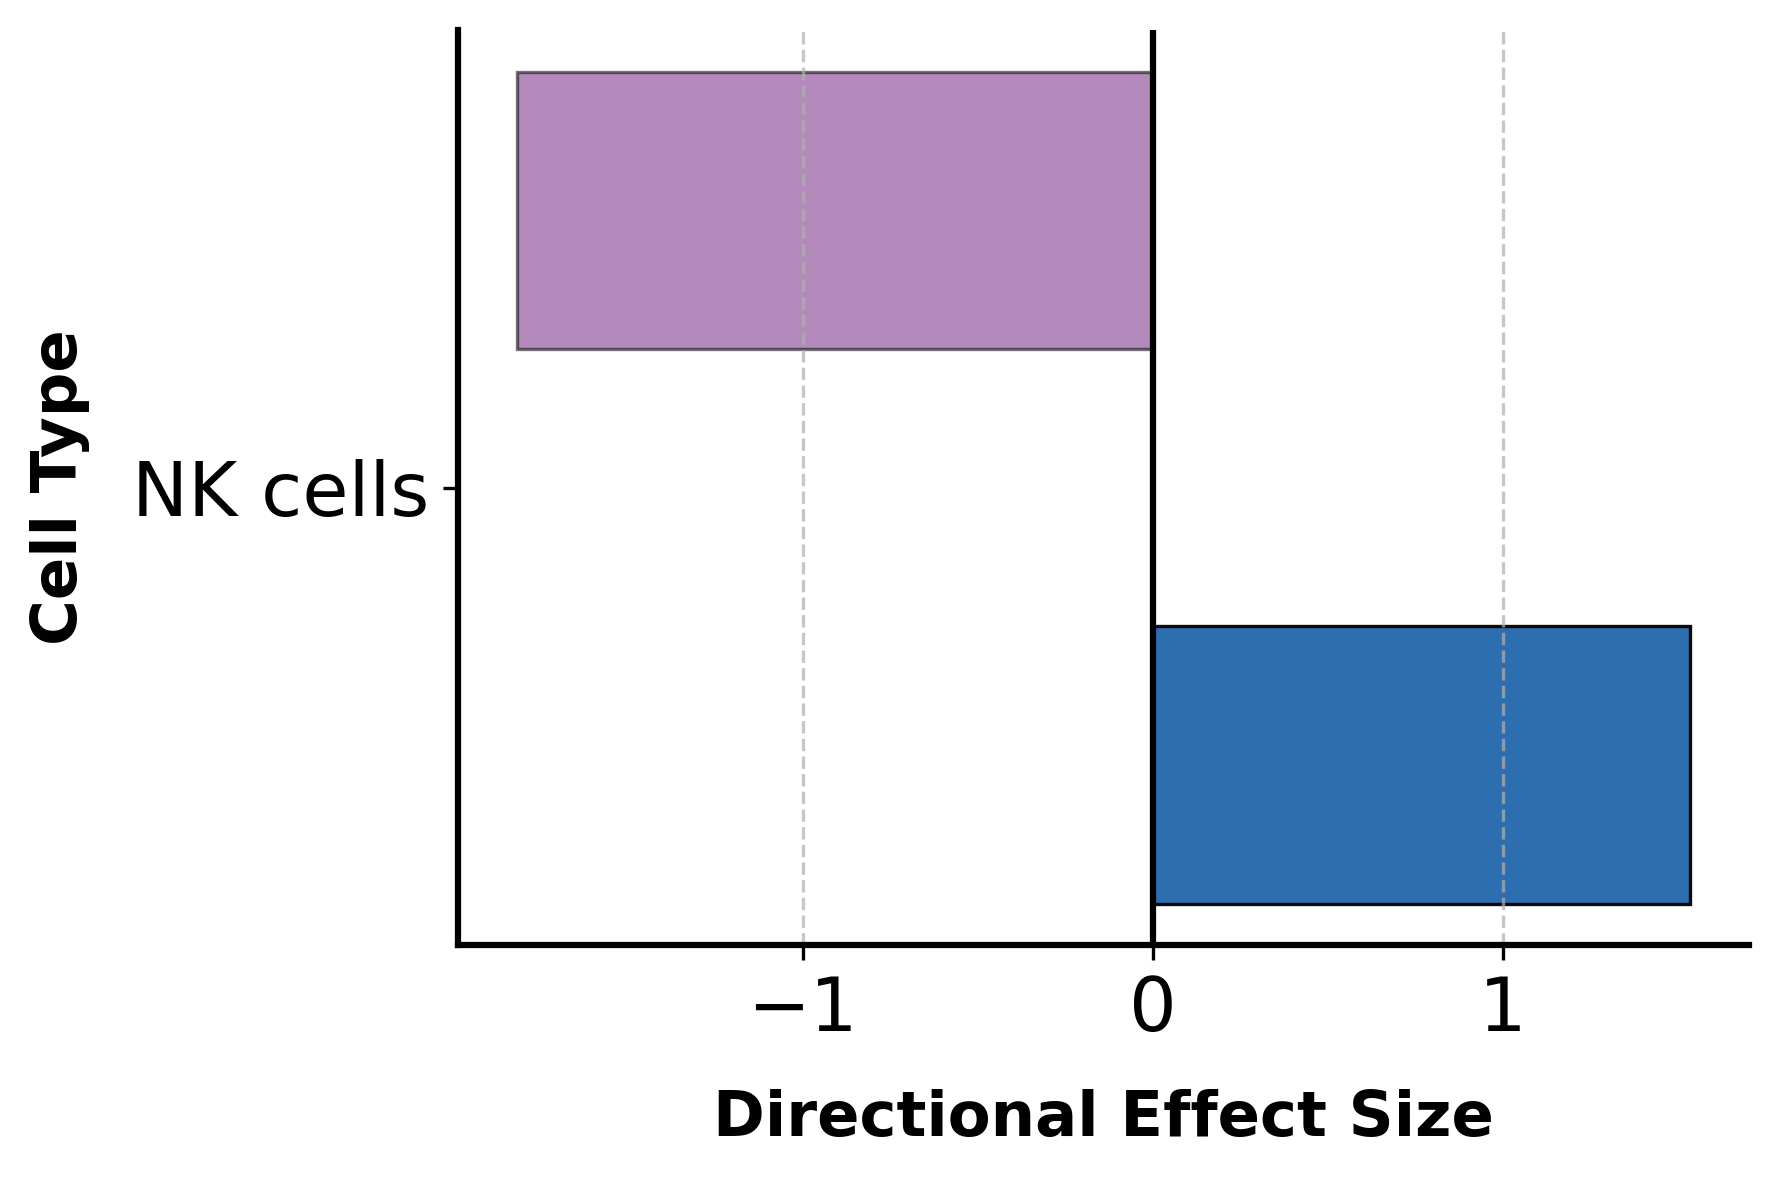

  ✅ Saved legend PNG: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_immune_coarse/publication_figures/stacked_bar_plots/legend_effectsize_updown_immune_coarse.png
  ✅ Saved legend SVG: /content/drive/MyDrive/new_dysfunction/svg_images/stacked_bar_plots/immune_coarse/legend_effectsize_updown_immune_coarse.svg


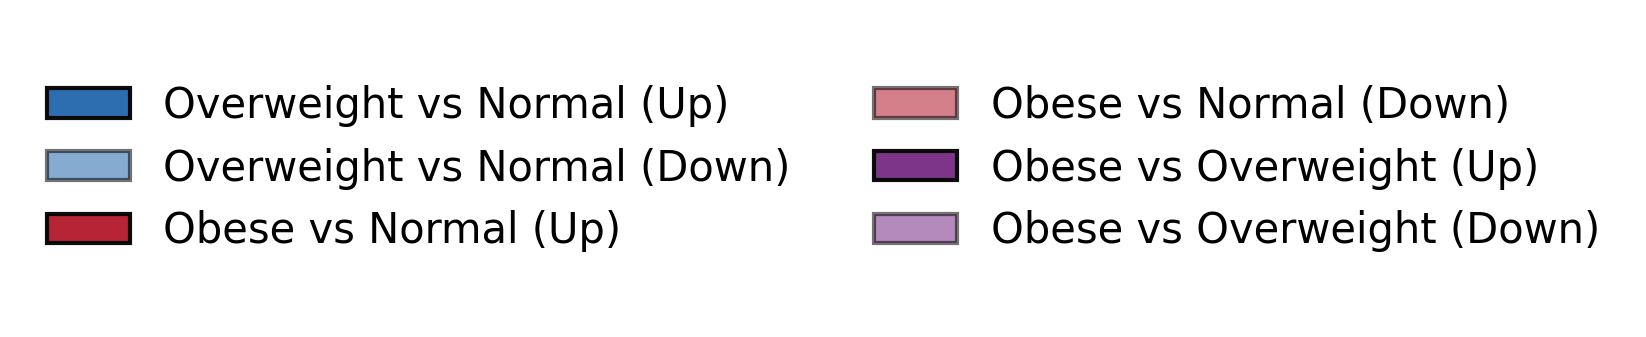


✅ ALL COMPARTMENTS COMPLETED

OUTPUT LOCATIONS:

Non-Immune:
  PNG: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_nonimmune/publication_figures/stacked_bar_plots
  SVG: /content/drive/MyDrive/new_dysfunction/svg_images/stacked_bar_plots/nonimmune

Immune Fine:
  PNG: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_immune_fine/publication_figures/stacked_bar_plots
  SVG: /content/drive/MyDrive/new_dysfunction/svg_images/stacked_bar_plots/immune_fine

Immune Coarse:
  PNG: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_immune_coarse/publication_figures/stacked_bar_plots
  SVG: /content/drive/MyDrive/new_dysfunction/svg_images/stacked_bar_plots/immune_coarse


In [ ]:
# Colab-ready: Directional effect-size (Up vs Down) plot (compartmentalized)
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# -----------------------------
# CONFIG
# -----------------------------
BASE = "/content/drive/MyDrive/new_dysfunction"

# SVG output configuration
SVG_BASE = f"{BASE}/svg_images"
SVG_SUBFOLDER = "stacked_bar_plots"

# -----------------------------
# AESTHETICS
# -----------------------------
FIGURE_WIDTH = 2
FIGURE_HEIGHT = 4
FIGURE_DPI = 300
BAR_HEIGHT = 0.7
BAR_ALPHA = 0.95
BAR_ALPHA_DOWN = 0.55
BAR_EDGE_LINEWIDTH = 0.8
FONT_SIZE_BASE = 9
FONT_SIZE_TITLE = 18
FONT_SIZE_LABEL = 15
FONT_SIZE_TICK = 18
FONT_SIZE_LEGEND = 10
AXES_LINEWIDTH = 1.5
GRID_ALPHA = 0.7
GRID_LINESTYLE = '--'

COMPARISON_ORDER = ["overweight", "obese", "obese_vs_overweight"]
COMPARISON_LABELS = {
    "overweight": "Overweight vs Normal",
    "obese": "Obese vs Normal",
    "obese_vs_overweight": "Obese vs Overweight"
}
COMPARISON_COLORS = {
    "overweight": "#2166ac",
    "obese": "#b2182b",
    "obese_vs_overweight": "#762a83"
}

plt.rcParams.update({
    "figure.dpi": FIGURE_DPI,
    "savefig.dpi": FIGURE_DPI,
    "font.size": FONT_SIZE_BASE,
    "axes.titlesize": FONT_SIZE_TITLE,
    "axes.labelsize": FONT_SIZE_LABEL,
    "xtick.labelsize": FONT_SIZE_TICK,
    "ytick.labelsize": FONT_SIZE_TICK,
    "axes.linewidth": AXES_LINEWIDTH,
})

# -----------------------------
# COMPARTMENTS + CELL_GROUPS
# -----------------------------
COMPARTMENTS = {
    'nonimmune': {
        'dir': f"{BASE}/bayesian_hierarchical_3group_nonimmune",
        'name': 'Non-Immune'
    },
    'immune_fine': {
        'dir': f"{BASE}/bayesian_hierarchical_3group_immune_fine",
        'name': 'Immune Fine'
    },
    'immune_coarse': {
        'dir': f"{BASE}/bayesian_hierarchical_3group_immune_coarse",
        'name': 'Immune Coarse'
    }
}

CELL_GROUPS = {
    "nonimmune": {
        "Acinar", "Adipocytes", "Endothelial", "Fibroblasts",
        "Islet endocrine", "Neural", "Normal ductal", "Pericytes SMC",
        "Schwann", "Stellate", "Tumor classical", "Tumor epithelial",
        "apCAF", "iCAF"
    },
    "immune_fine": {
        "B cells naive", "CD4 T Th1", "CD4 T naive", "CD4 T regulatory", "CD4 Tfh",
        "CD8 T effector", "CD8 T exhausted", "CD8 Tmemory",
        "Monocyte classical", "Monocyte non-classical",
        "T gamma delta", "TAM", "mDC", "pDC"
    },
    "immune_coarse": {
        "B cells", "Basophils", "CD4+ T cells", "CD8 T general",
        "Dendritic cells", "Monocytes", "NK cells", "T cells"
    }
}

# -----------------------------
# helpers
# -----------------------------
def parse_feature(feature):
    if "||" in feature:
        cell_type, signature = feature.split("||", 1)
        cell_type = cell_type.replace("_", " ")
        signature = re.sub(r"_Signature$", "", signature).replace("_", " ")
        return cell_type, signature
    return "Unknown", feature.replace("_", " ")

def canon_cell(cell_like):
    s = str(cell_like).strip()
    s = re.sub(r"[_\-]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    ALIASES = {
        "acinar": "Acinar", "adipocytes": "Adipocytes", "b cells": "B cells",
        "b cells naive": "B cells naive", "basophils": "Basophils",
        "cd4+ t cells": "CD4+ T cells", "cd8 t general": "CD8 T general",
        "endothelial": "Endothelial", "fibroblasts": "Fibroblasts",
        "islet endocrine": "Islet endocrine", "neural": "Neural",
        "normal ductal": "Normal ductal", "pericytes smc": "Pericytes SMC",
        "schwann": "Schwann", "stellate": "Stellate",
        "tumor classical": "Tumor classical", "tumor epithelial": "Tumor epithelial",
        "apcaf": "apCAF", "icaf": "iCAF",
        "b cells naive": "B cells naive", "cd4 t th1": "CD4 T Th1",
        "cd4 t naive": "CD4 T naive", "cd4 t regulatory": "CD4 T regulatory",
        "cd4 tfh": "CD4 Tfh", "cd8 t effector": "CD8 T effector",
        "cd8 t exhausted": "CD8 T exhausted", "cd8 tmemory": "CD8 Tmemory",
        "monocyte classical": "Monocyte classical",
        "monocyte non classical": "Monocyte non-classical",
        "t gamma delta": "T gamma delta", "tam": "TAM",
        "mdc": "mDC", "pdc": "pDC",
        "b cells": "B cells", "cd4+ t cells": "CD4+ T cells",
        "dendritic cells": "Dendritic cells", "monocytes": "Monocytes",
        "nk cells": "NK cells", "t cells": "T cells"
    }
    return ALIASES.get(s.lower(), s)

# -----------------------------
# core function
# -----------------------------
def create_effectsize_updown_for_df(df, out_base, svg_out_base, out_fname_suffix):
    df = df.copy()
    if 'feature' not in df.columns:
        raise ValueError("Input CSV must have a 'feature' column.")

    df['cell_type_parsed'], df['signature'] = zip(*df['feature'].apply(parse_feature))
    df['cell_canon'] = df['cell_type_parsed'].apply(canon_cell)

    records = []
    for comp in COMPARISON_ORDER:
        mean_col = f'{comp}_vs_normal_mean' if comp != 'obese_vs_overweight' else f'{comp}_mean'
        cred_col = f'{comp}_credible'

        if mean_col not in df.columns or cred_col not in df.columns:
            print(f"    Missing columns for {comp}: {mean_col} or {cred_col}")
            continue

        sub = df[df[cred_col].astype(bool)].copy()
        if sub.empty:
            print(f"   No credible effects for {comp}")
            continue

        for ct in sub['cell_canon'].unique():
            ct_df = sub[sub['cell_canon'] == ct]
            pos_sum = ct_df[ct_df[mean_col] > 0][mean_col].sum()
            neg_sum = ct_df[ct_df[mean_col] < 0][mean_col].sum()
            records.append({'cell_canon': ct, 'comparison': comp, 'pos_sum': pos_sum, 'neg_sum': neg_sum})

    if not records:
        print(f"  No directional effect-size data found for {out_fname_suffix}")
        return

    eff = pd.DataFrame.from_records(records)
    pos_pivot = eff.pivot(index='cell_canon', columns='comparison', values='pos_sum').fillna(0)
    neg_pivot = eff.pivot(index='cell_canon', columns='comparison', values='neg_sum').fillna(0)
    pos_pivot = pos_pivot.reindex(columns=COMPARISON_ORDER, fill_value=0)
    neg_pivot = neg_pivot.reindex(columns=COMPARISON_ORDER, fill_value=0)

    total_mag = pos_pivot.sum(axis=1) + abs(neg_pivot.sum(axis=1))
    order = total_mag.sort_values(ascending=True).index
    pos_pivot = pos_pivot.loc[order]
    neg_pivot = neg_pivot.loc[order]

    fig, ax = plt.subplots(figsize=(FIGURE_WIDTH + 4, FIGURE_HEIGHT), dpi=FIGURE_DPI)

    n_cells = len(pos_pivot.index)
    n_comp = len(COMPARISON_ORDER)
    bar_height = 0.8
    group_gap = 0.8
    group_centers = np.arange(n_cells) * (n_comp * bar_height + group_gap)

    for idx, comp in enumerate(COMPARISON_ORDER):
        pos_vals = pos_pivot[comp].values
        neg_vals = neg_pivot[comp].values
        color = COMPARISON_COLORS[comp]
        offset = (idx - (n_comp - 1) / 2) * bar_height

        ax.barh(group_centers + offset, pos_vals, bar_height,
                color=color, alpha=BAR_ALPHA, edgecolor='black', linewidth=BAR_EDGE_LINEWIDTH)
        ax.barh(group_centers + offset, neg_vals, bar_height,
                color=color, alpha=BAR_ALPHA_DOWN, edgecolor='black', linewidth=BAR_EDGE_LINEWIDTH)

    ax.set_yticks(group_centers)
    ax.set_yticklabels(pos_pivot.index, fontsize=FONT_SIZE_TICK)
    ax.set_ylabel('Cell Type', fontsize=FONT_SIZE_LABEL, fontweight='bold', labelpad=10)
    ax.set_xlabel('Directional Effect Size', fontsize=FONT_SIZE_LABEL, fontweight='bold', labelpad=10)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', alpha=GRID_ALPHA, linestyle=GRID_LINESTYLE)
    ax.axvline(0, color='black', linewidth=1.5, zorder=5)
    plt.tight_layout()

    # Save PNG
    outfile = os.path.join(out_base, f"effectsize_updown_{out_fname_suffix}.png")
    plt.savefig(outfile, dpi=FIGURE_DPI, bbox_inches="tight")
    print(f"  Saved PNG: {outfile}")

    # Save SVG
    svg_outfile = os.path.join(svg_out_base, f"effectsize_updown_{out_fname_suffix}.svg")
    plt.savefig(svg_outfile, format='svg', bbox_inches="tight")
    print(f"  Saved SVG: {svg_outfile}")

    plt.show()
    plt.close(fig)

    # Create legend
    legend_elements = []
    for comp in COMPARISON_ORDER:
        color = COMPARISON_COLORS[comp]
        legend_elements.append(plt.Rectangle((0,0),1,1, facecolor=color, alpha=BAR_ALPHA,
                                             edgecolor='black', label=f'{COMPARISON_LABELS[comp]} (Up)'))
        legend_elements.append(plt.Rectangle((0,0),1,1, facecolor=color, alpha=BAR_ALPHA_DOWN,
                                             edgecolor='black', label=f'{COMPARISON_LABELS[comp]} (Down)'))

    lg_fig, lg_ax = plt.subplots(figsize=(6, 1.2), dpi=FIGURE_DPI)
    lg_ax.axis('off')
    lg_ax.legend(handles=legend_elements, loc='center', frameon=False, ncol=2, fontsize=FONT_SIZE_LEGEND)

    # Save PNG legend
    legend_path = os.path.join(out_base, f"legend_effectsize_updown_{out_fname_suffix}.png")
    lg_fig.savefig(legend_path, bbox_inches='tight', dpi=FIGURE_DPI, facecolor='white')
    print(f"  Saved legend PNG: {legend_path}")

    # Save SVG legend
    svg_legend_path = os.path.join(svg_out_base, f"legend_effectsize_updown_{out_fname_suffix}.svg")
    lg_fig.savefig(svg_legend_path, format='svg', bbox_inches='tight', facecolor='white')
    print(f"  Saved legend SVG: {svg_legend_path}")

    plt.show()
    plt.close(lg_fig)

# -----------------------------
# Run per compartment
# -----------------------------
print("="*80)
print("DIRECTIONAL EFFECT-SIZE PLOTS (STACKED BAR)")
print("="*80)

for comp_key, info in COMPARTMENTS.items():
    comp_name = info['name']
    comp_dir = info['dir']

    print("\n" + "="*60)
    print(f"COMPARTMENT: {comp_name} ({comp_key})")

    # Load compartment-specific ROPE file
    rope_csv = os.path.join(comp_dir, "bayesian_results_3group_with_rope.csv")

    if not os.path.exists(rope_csv):
        print(f"  ROPE file not found: {rope_csv}")
        continue

    print(f" Loading: {rope_csv}")
    df = pd.read_csv(rope_csv)
    print(f"  Rows loaded: {len(df)}")

    # Parse cell types
    if 'cell_type' in df.columns and df['cell_type'].notna().any():
        df['cell_type_parsed'] = df['cell_type']
        df['signature'] = df['feature'].apply(lambda f: parse_feature(f)[1])
    else:
        df['cell_type_parsed'], df['signature'] = zip(*df['feature'].apply(parse_feature))

    df['cell_canon'] = df['cell_type_parsed'].apply(canon_cell)

    # Filter by cell groups
    wanted = CELL_GROUPS.get(comp_key, None)
    if wanted is not None:
        filtered = df[df['cell_canon'].isin(wanted)].copy()
        if filtered.empty:
            print(f"  After filtering, 0 rows remain — skipping {comp_key}.")
            continue
        else:
            print(f"  Filtered to {len(filtered)} rows. Cells: {sorted(filtered['cell_canon'].unique())}")
        df_to_plot = filtered
    else:
        df_to_plot = df

    # Create output directories
    out_dir = os.path.join(comp_dir, "publication_figures", "stacked_bar_plots")
    os.makedirs(out_dir, exist_ok=True)

    svg_out_dir = os.path.join(SVG_BASE, SVG_SUBFOLDER, comp_key)
    os.makedirs(svg_out_dir, exist_ok=True)

    print(f"\n  Creating stacked bar plots...")
    create_effectsize_updown_for_df(df_to_plot, out_dir, svg_out_dir, comp_key)

print("\n" + "="*80)
print("ALL COMPARTMENTS COMPLETED")
print("="*80)

# Print output summary
print("\nOUTPUT LOCATIONS:")
for comp_key, info in COMPARTMENTS.items():
    comp_dir = info['dir']
    png_dir = os.path.join(comp_dir, "publication_figures", "stacked_bar_plots")
    svg_dir = os.path.join(SVG_BASE, SVG_SUBFOLDER, comp_key)

    print(f"\n{info['name']}:")
    print(f"  PNG: {png_dir}")
    print(f"  SVG: {svg_dir}")

##Stacekd bar plot counts

STACKED BAR PLOTS - CREDIBLE FEATURE COUNTS (COMPARTMENT-WHITELIST MODE)
  ✅ Loading compartment ROPE for master: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_nonimmune/bayesian_results_3group_with_rope.csv (nonimmune)
  ✅ Loading compartment ROPE for master: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_immune_fine/bayesian_results_3group_with_rope.csv (immune_fine)
  ✅ Loading compartment ROPE for master: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_immune_coarse/bayesian_results_3group_with_rope.csv (immune_coarse)
Master assembled: 130 rows from 3 compartment files
  Normalized overweight: using 'overweight_credible' -> overweight_credible (True: 49)
  Normalized obese: using 'obese_credible' -> obese_credible (True: 16)
  Normalized obese_vs_overweight: using 'obese_vs_overweight_credible' -> obese_vs_overweight_credible (True: 11)
  Saved legend PNG: /content/drive/MyDrive/new_dysfunction/svg_images/stacked_bar_p

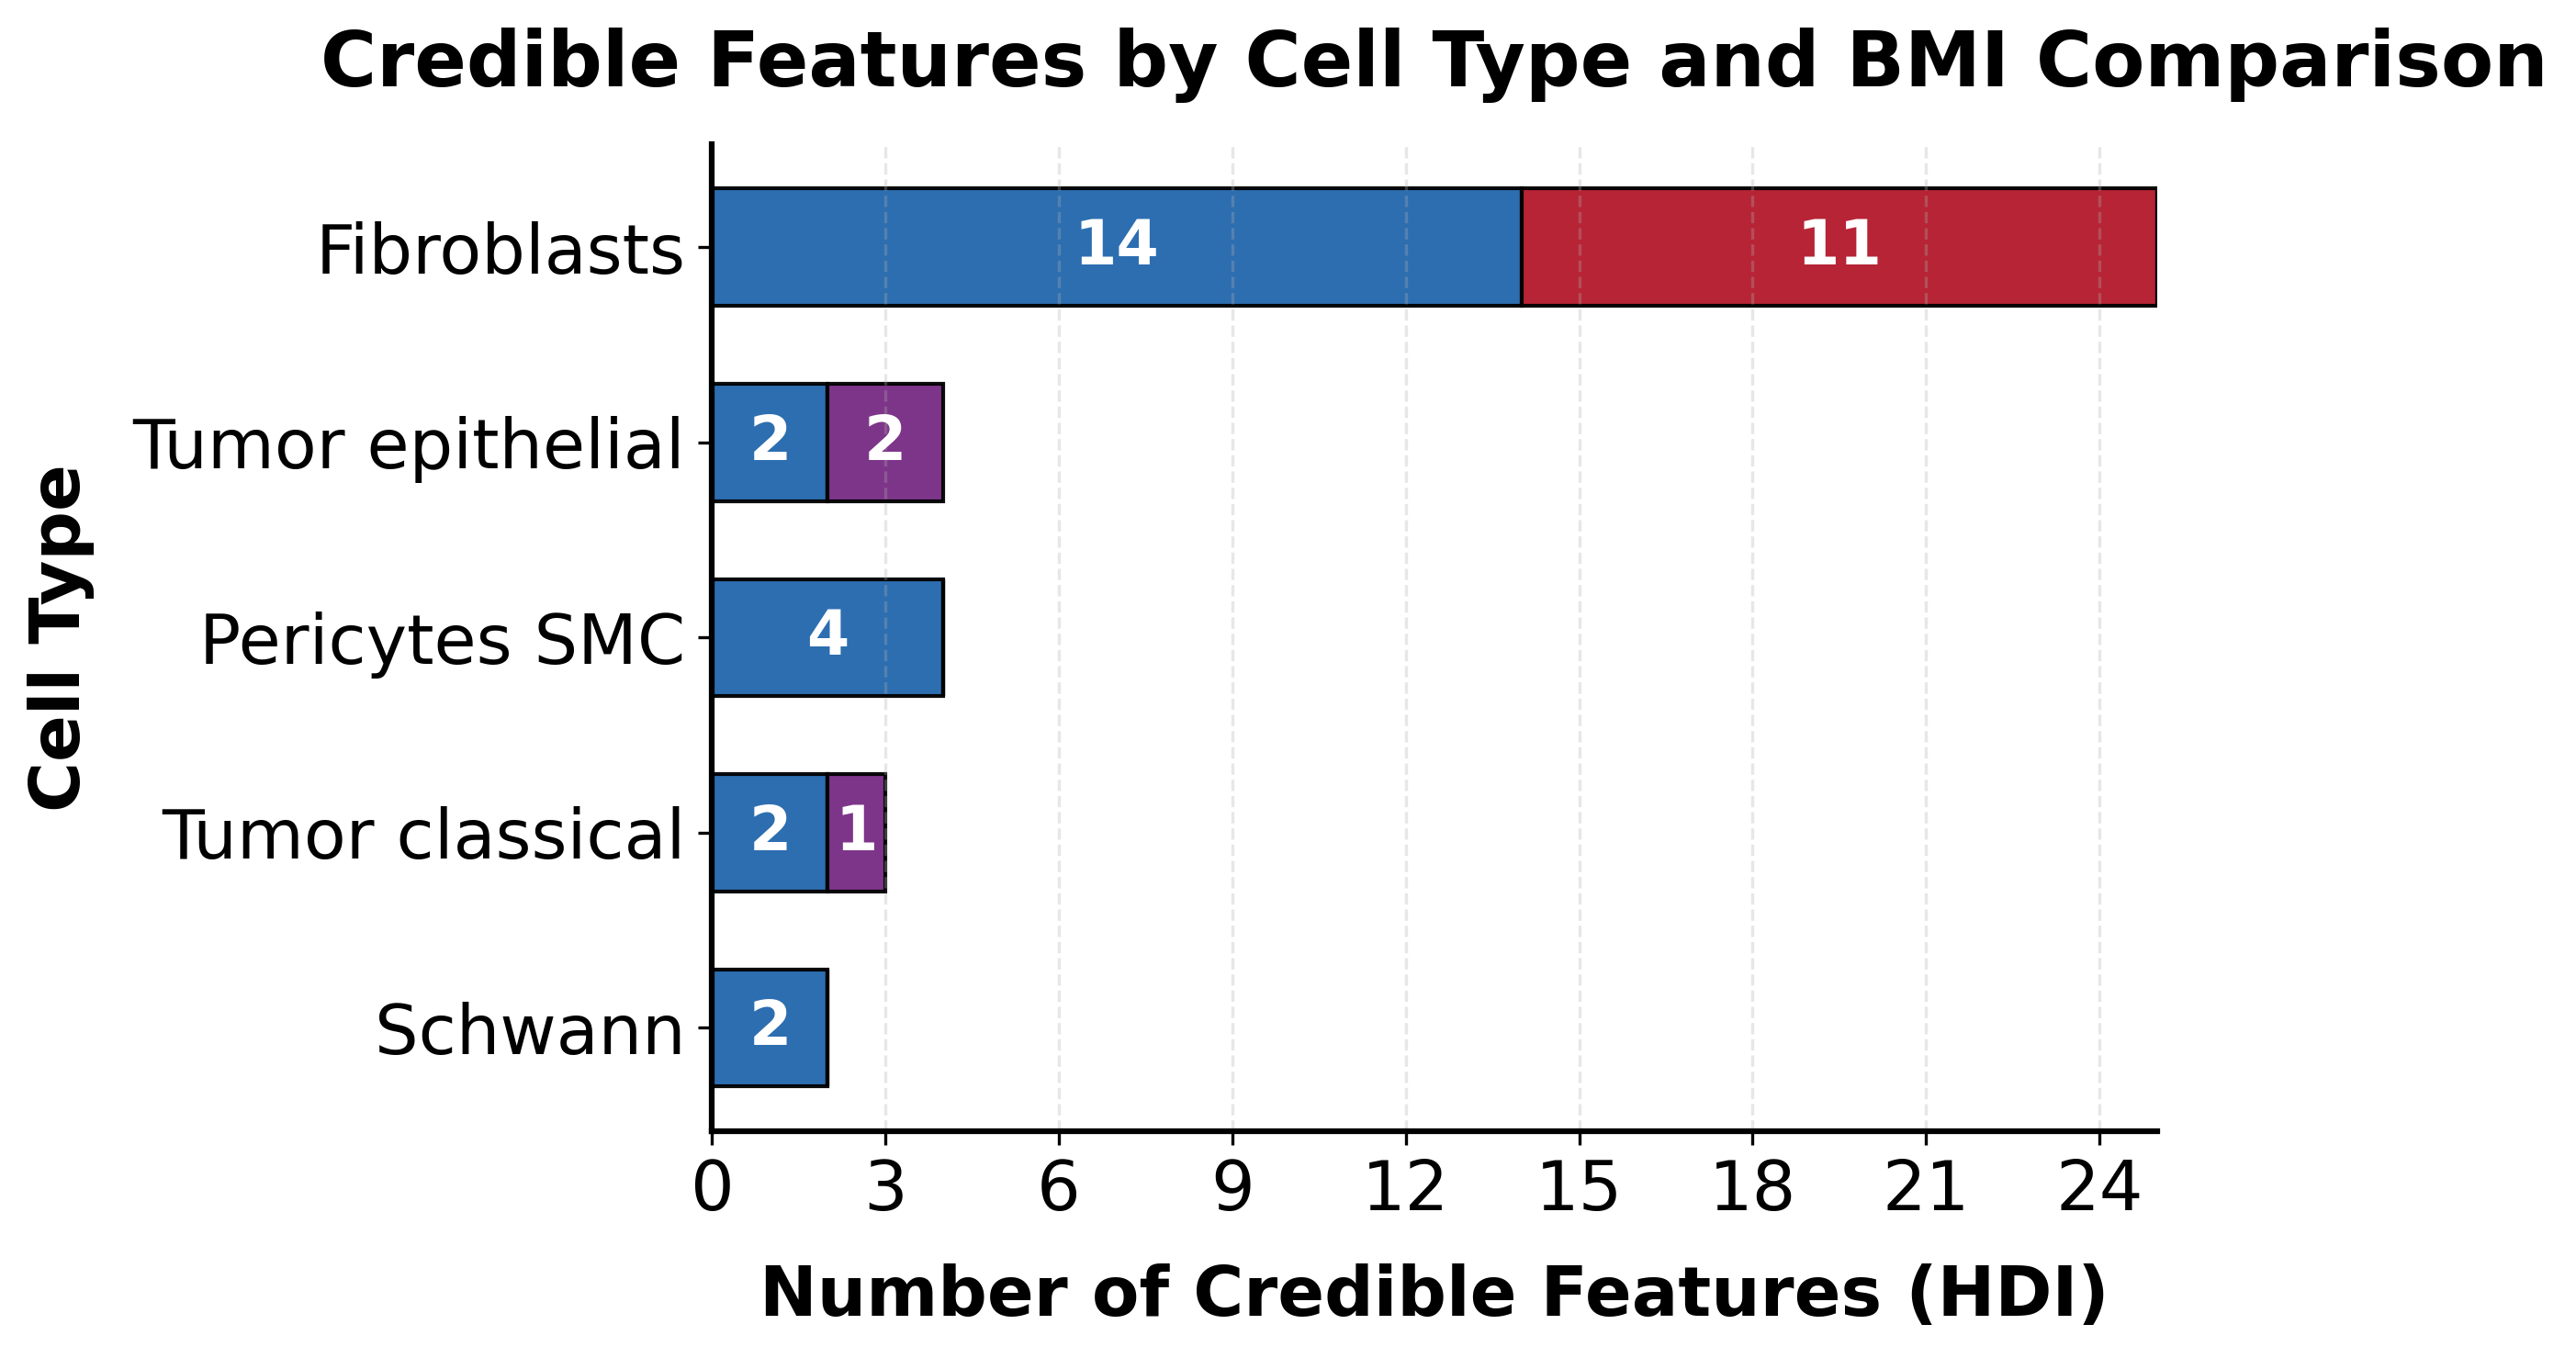

  [Non-Immune] Applied whitelist: 7 cells — rows 130 -> 57
    [Non-Immune] overweight: credible rows for effect size = 24
    [Non-Immune] obese: credible rows for effect size = 11
    [Non-Immune] obese_vs_overweight: credible rows for effect size = 3
  Saved labels: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_nonimmune/publication_figures/stacked_bar_plots/labels/cell_type_labels_effect_size_Non-Immune.txt
  Saved data table: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_nonimmune/publication_figures/stacked_bar_plots/data_tables/data_table_effect_size_Non-Immune.csv
  ✅ Saved PNG: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_nonimmune/publication_figures/stacked_bar_plots/stacked_bar_effect_size_Non-Immune.png
  ✅ Saved SVG: /content/drive/MyDrive/new_dysfunction/svg_images/stacked_bar_plots/nonimmune/stacked_bar_effect_size_Non-Immune.svg


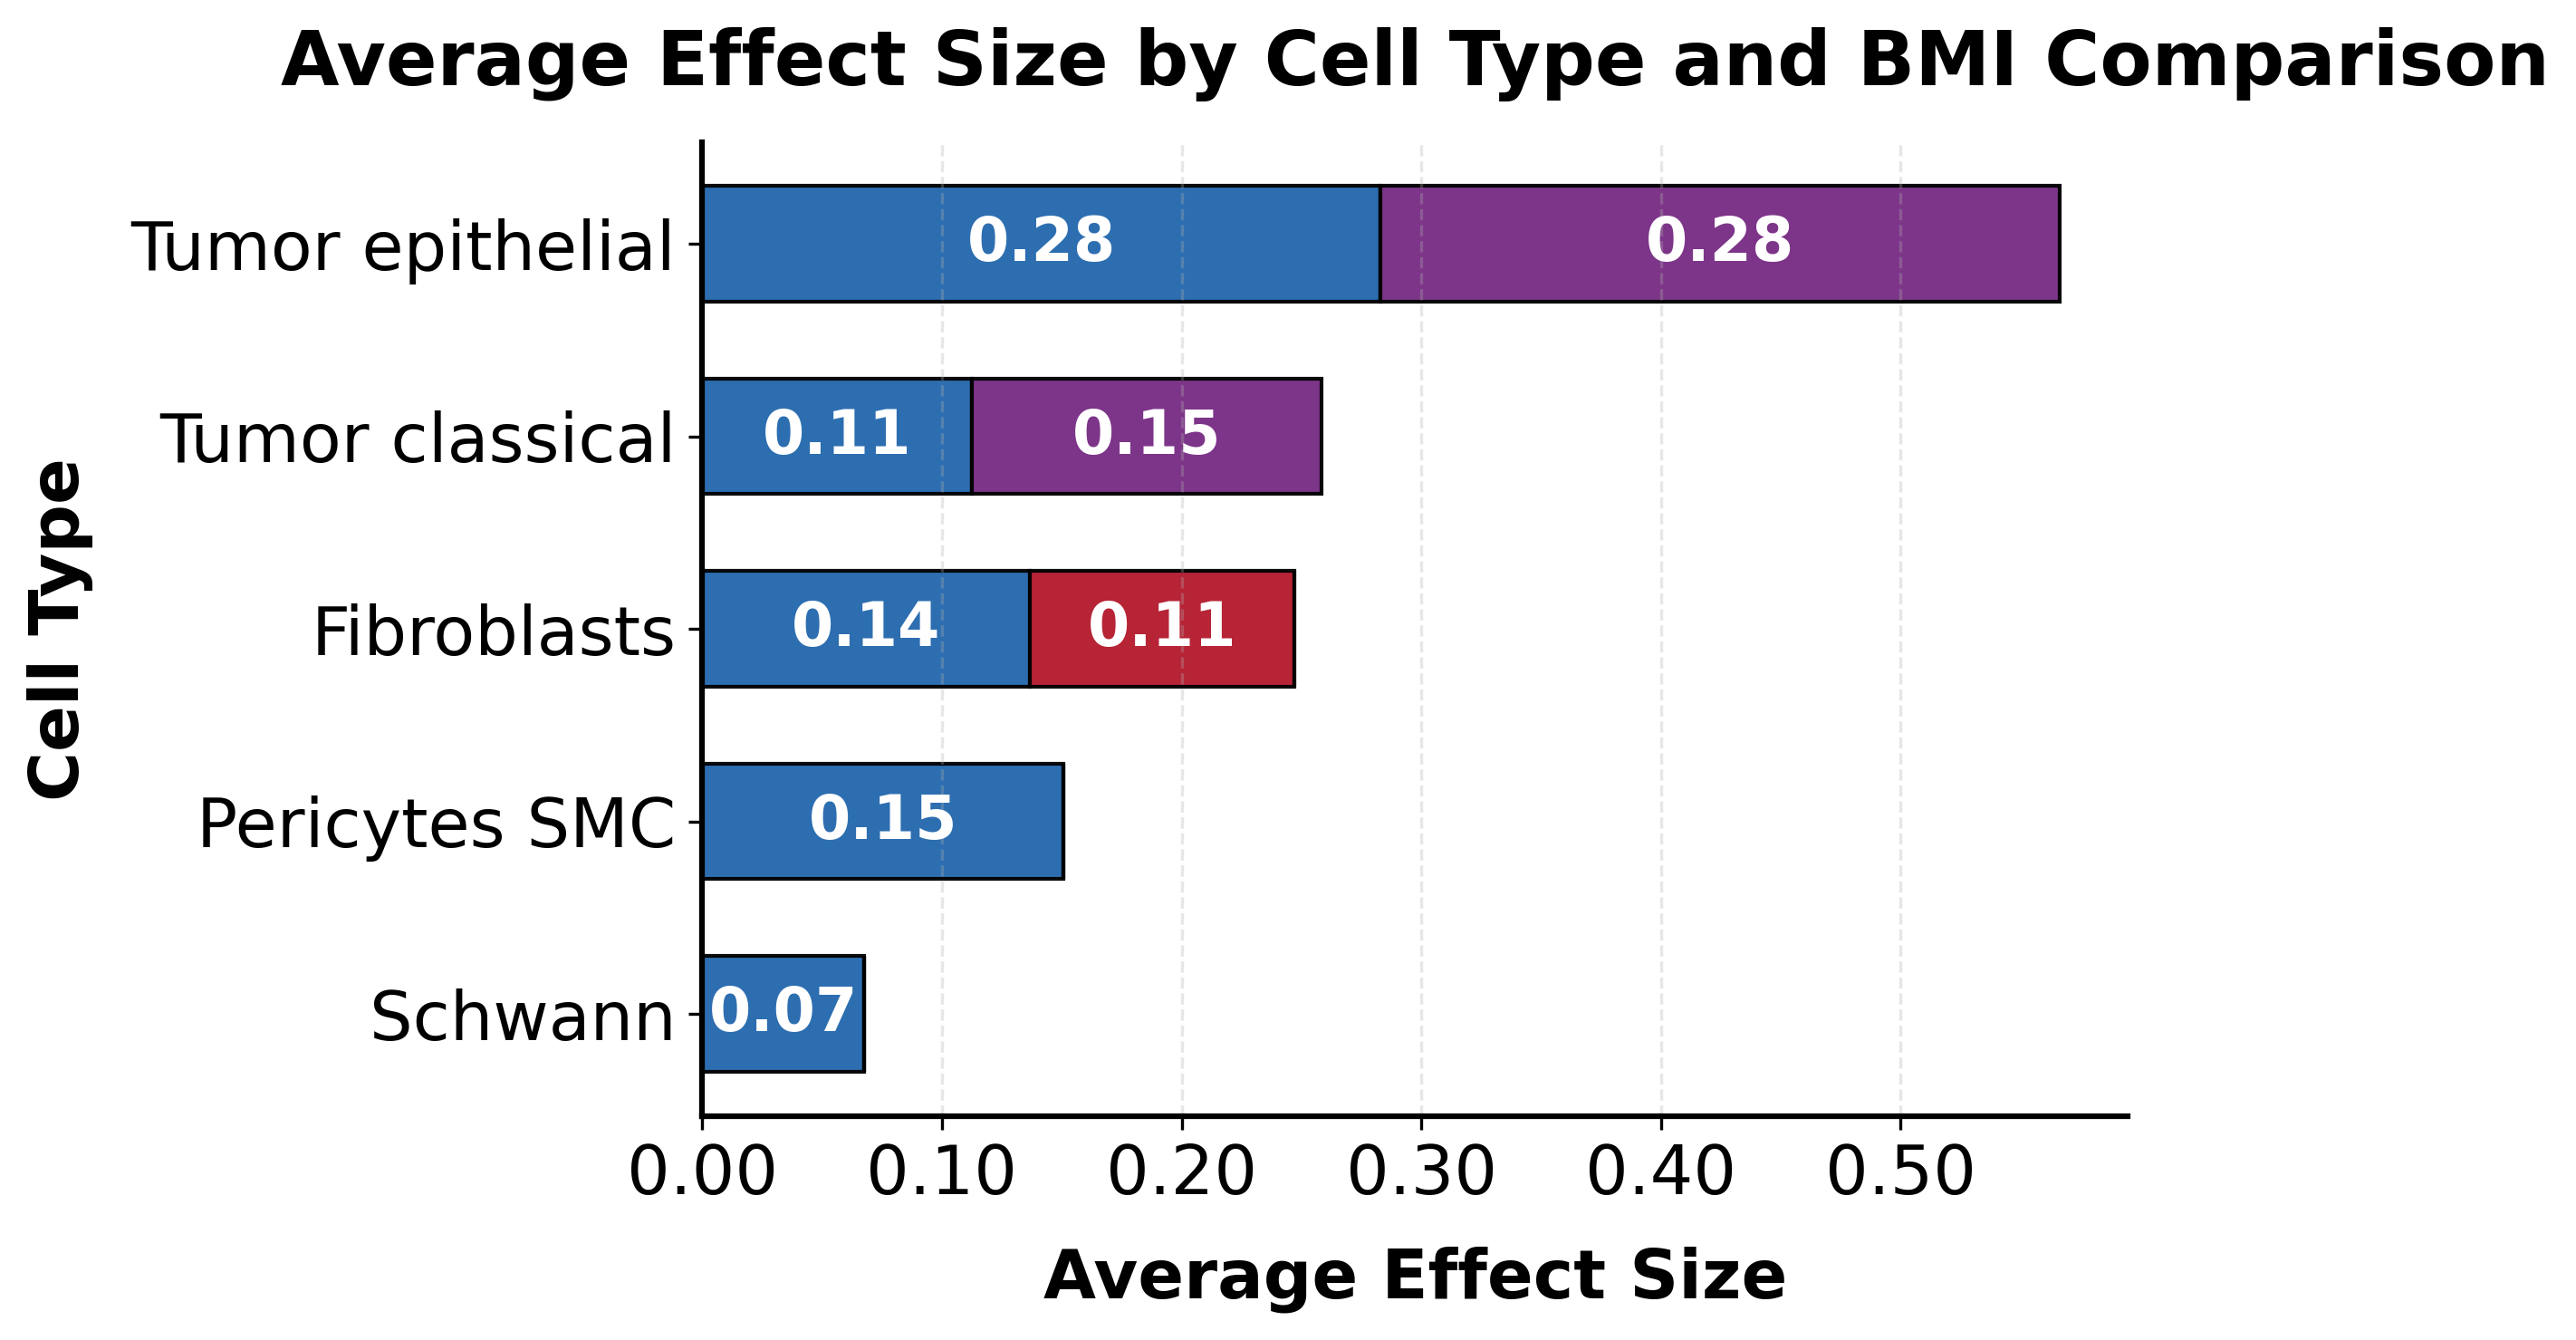


COMPARTMENT: Immune Fine (immune_fine)
  Whitelist size: 5; sample: ['B cells naive', 'Basophils', 'CD4 T naive', 'CD8 Tmemory', 'NK cells']
  [Immune Fine] Applied whitelist: 5 cells — rows 130 -> 64
    [Immune Fine] overweight: credible rows after whitelist = 25
    [Immune Fine] obese: credible rows after whitelist = 5
    [Immune Fine] obese_vs_overweight: credible rows after whitelist = 8
  Saved labels: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_immune_fine/publication_figures/stacked_bar_plots/labels/cell_type_labels_count_hdi_Immune_Fine.txt
  Saved data table: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_immune_fine/publication_figures/stacked_bar_plots/data_tables/data_table_count_hdi_Immune_Fine.csv
  ✅ Saved PNG: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_immune_fine/publication_figures/stacked_bar_plots/stacked_bar_count_hdi_Immune_Fine.png
  ✅ Saved SVG: /content/drive/MyDrive/new_dysfunction/svg_i

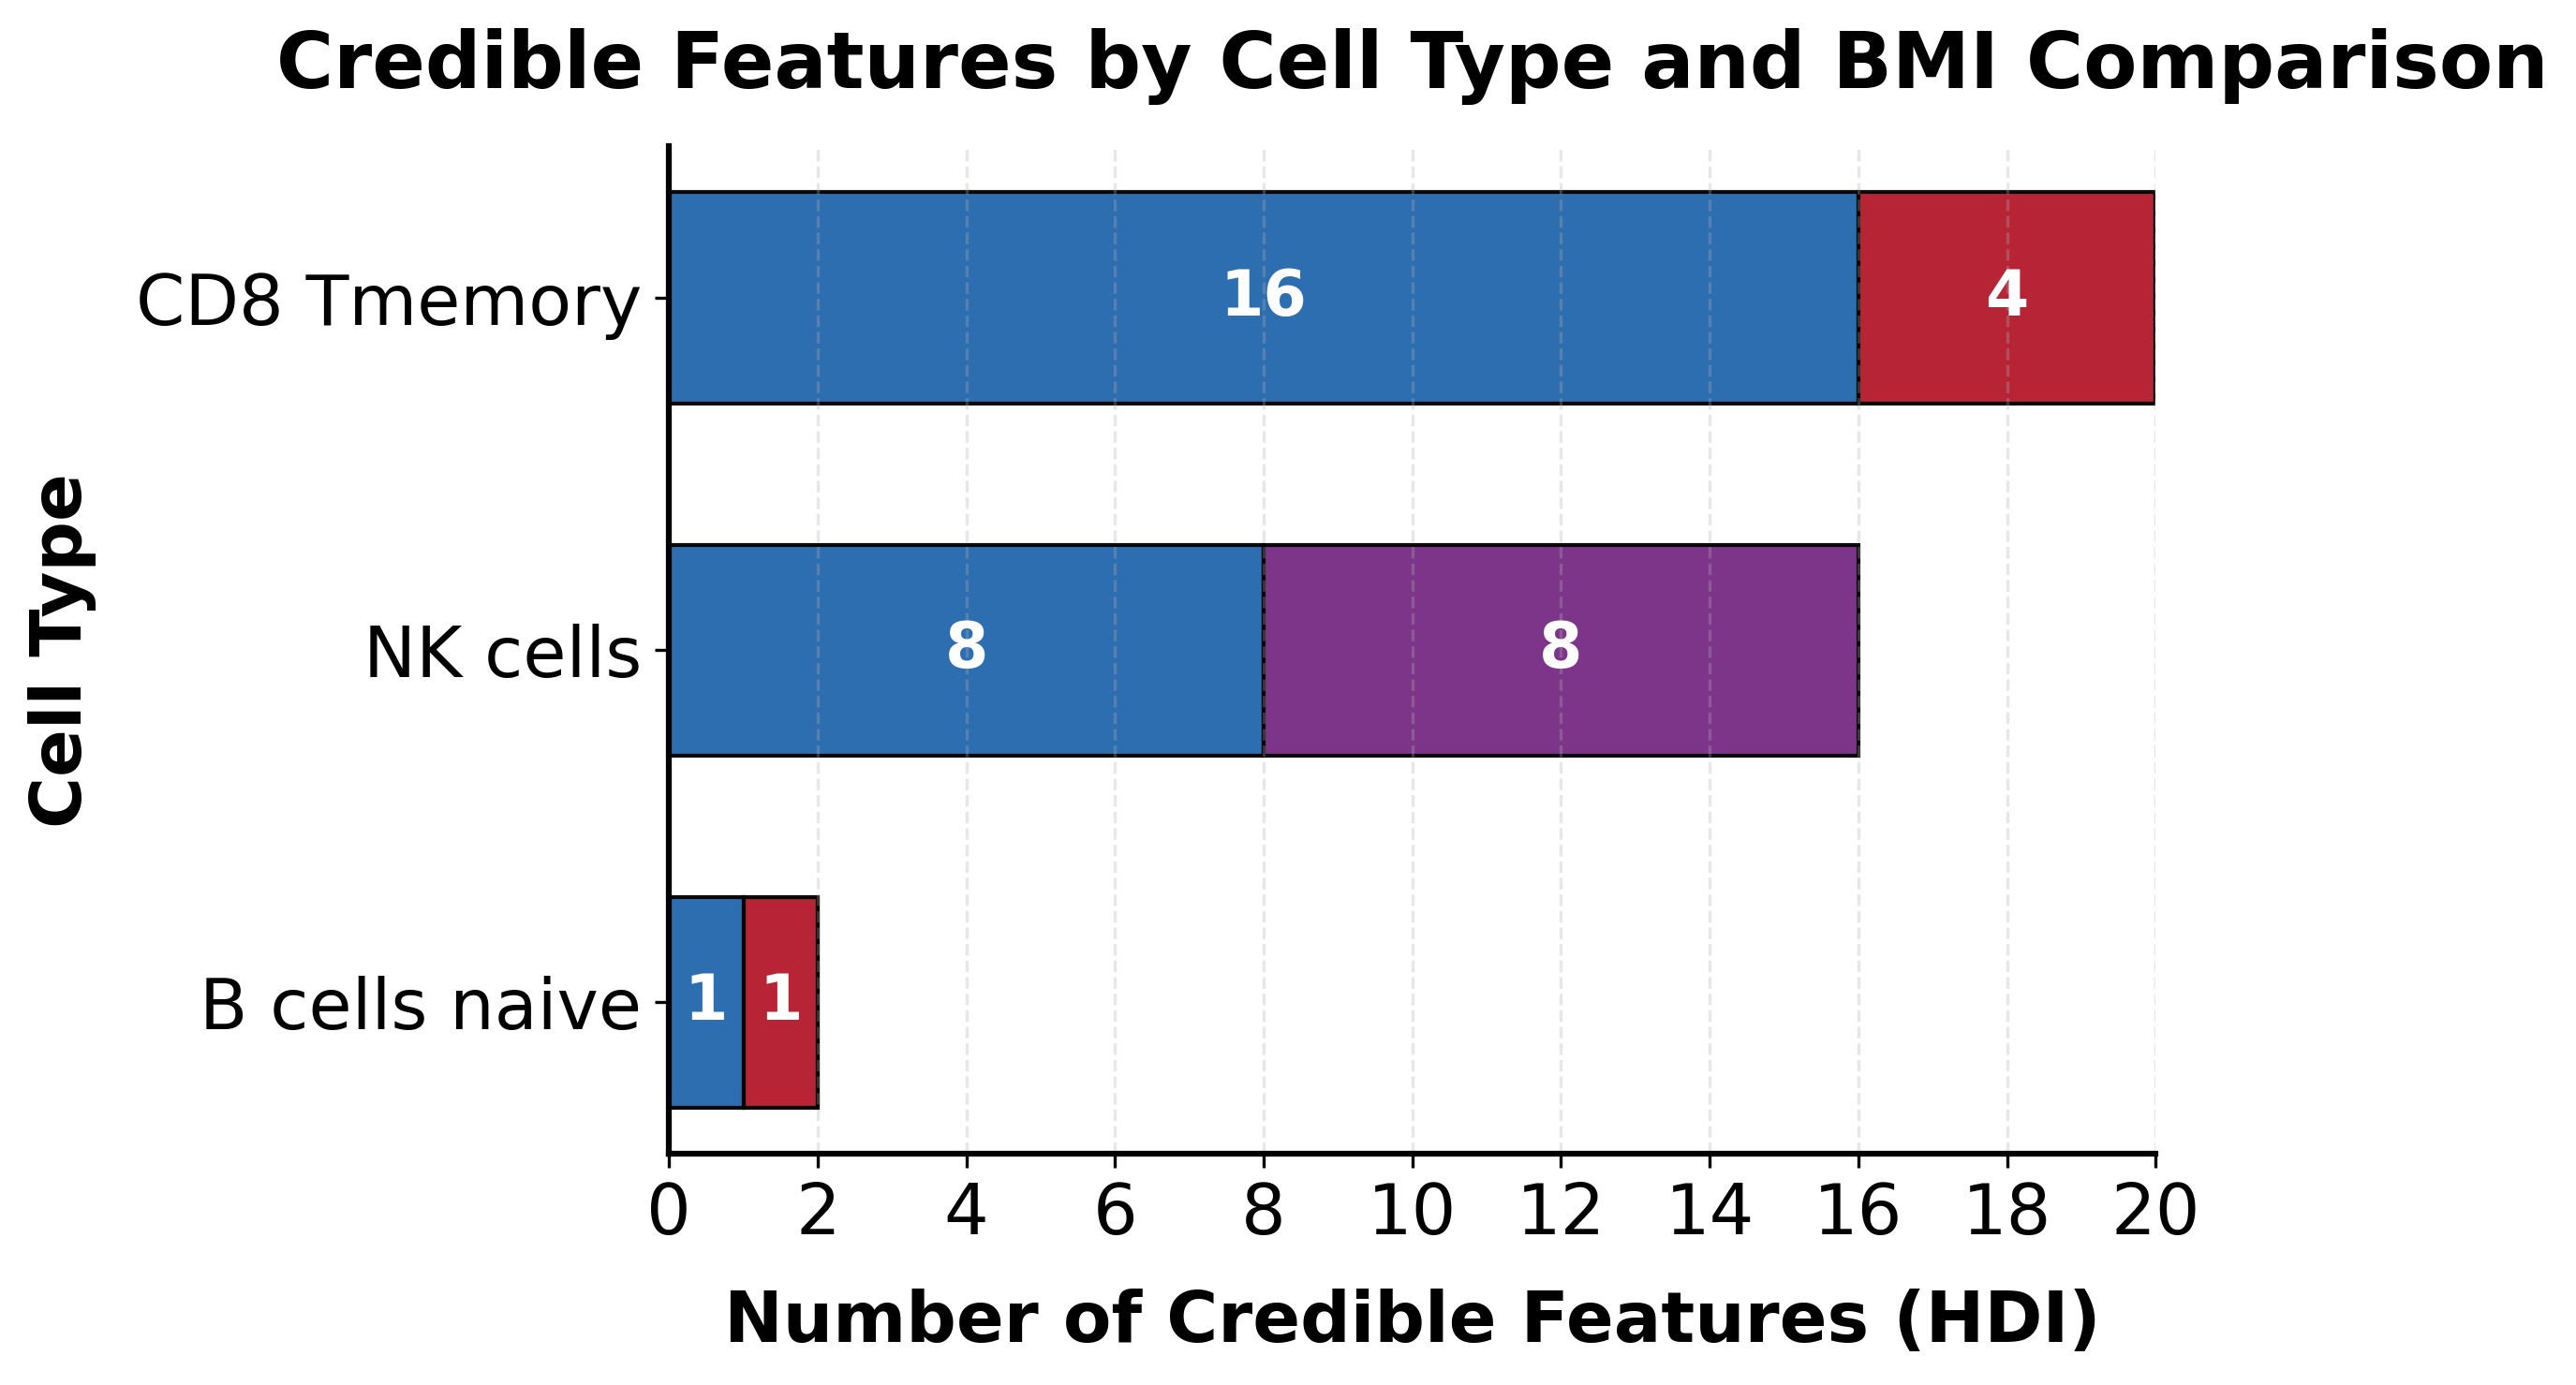

  [Immune Fine] Applied whitelist: 5 cells — rows 130 -> 64
    [Immune Fine] overweight: credible rows for effect size = 25
    [Immune Fine] obese: credible rows for effect size = 5
    [Immune Fine] obese_vs_overweight: credible rows for effect size = 8
  Saved labels: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_immune_fine/publication_figures/stacked_bar_plots/labels/cell_type_labels_effect_size_Immune_Fine.txt
  Saved data table: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_immune_fine/publication_figures/stacked_bar_plots/data_tables/data_table_effect_size_Immune_Fine.csv
  ✅ Saved PNG: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_immune_fine/publication_figures/stacked_bar_plots/stacked_bar_effect_size_Immune_Fine.png
  ✅ Saved SVG: /content/drive/MyDrive/new_dysfunction/svg_images/stacked_bar_plots/immune_fine/stacked_bar_effect_size_Immune_Fine.svg


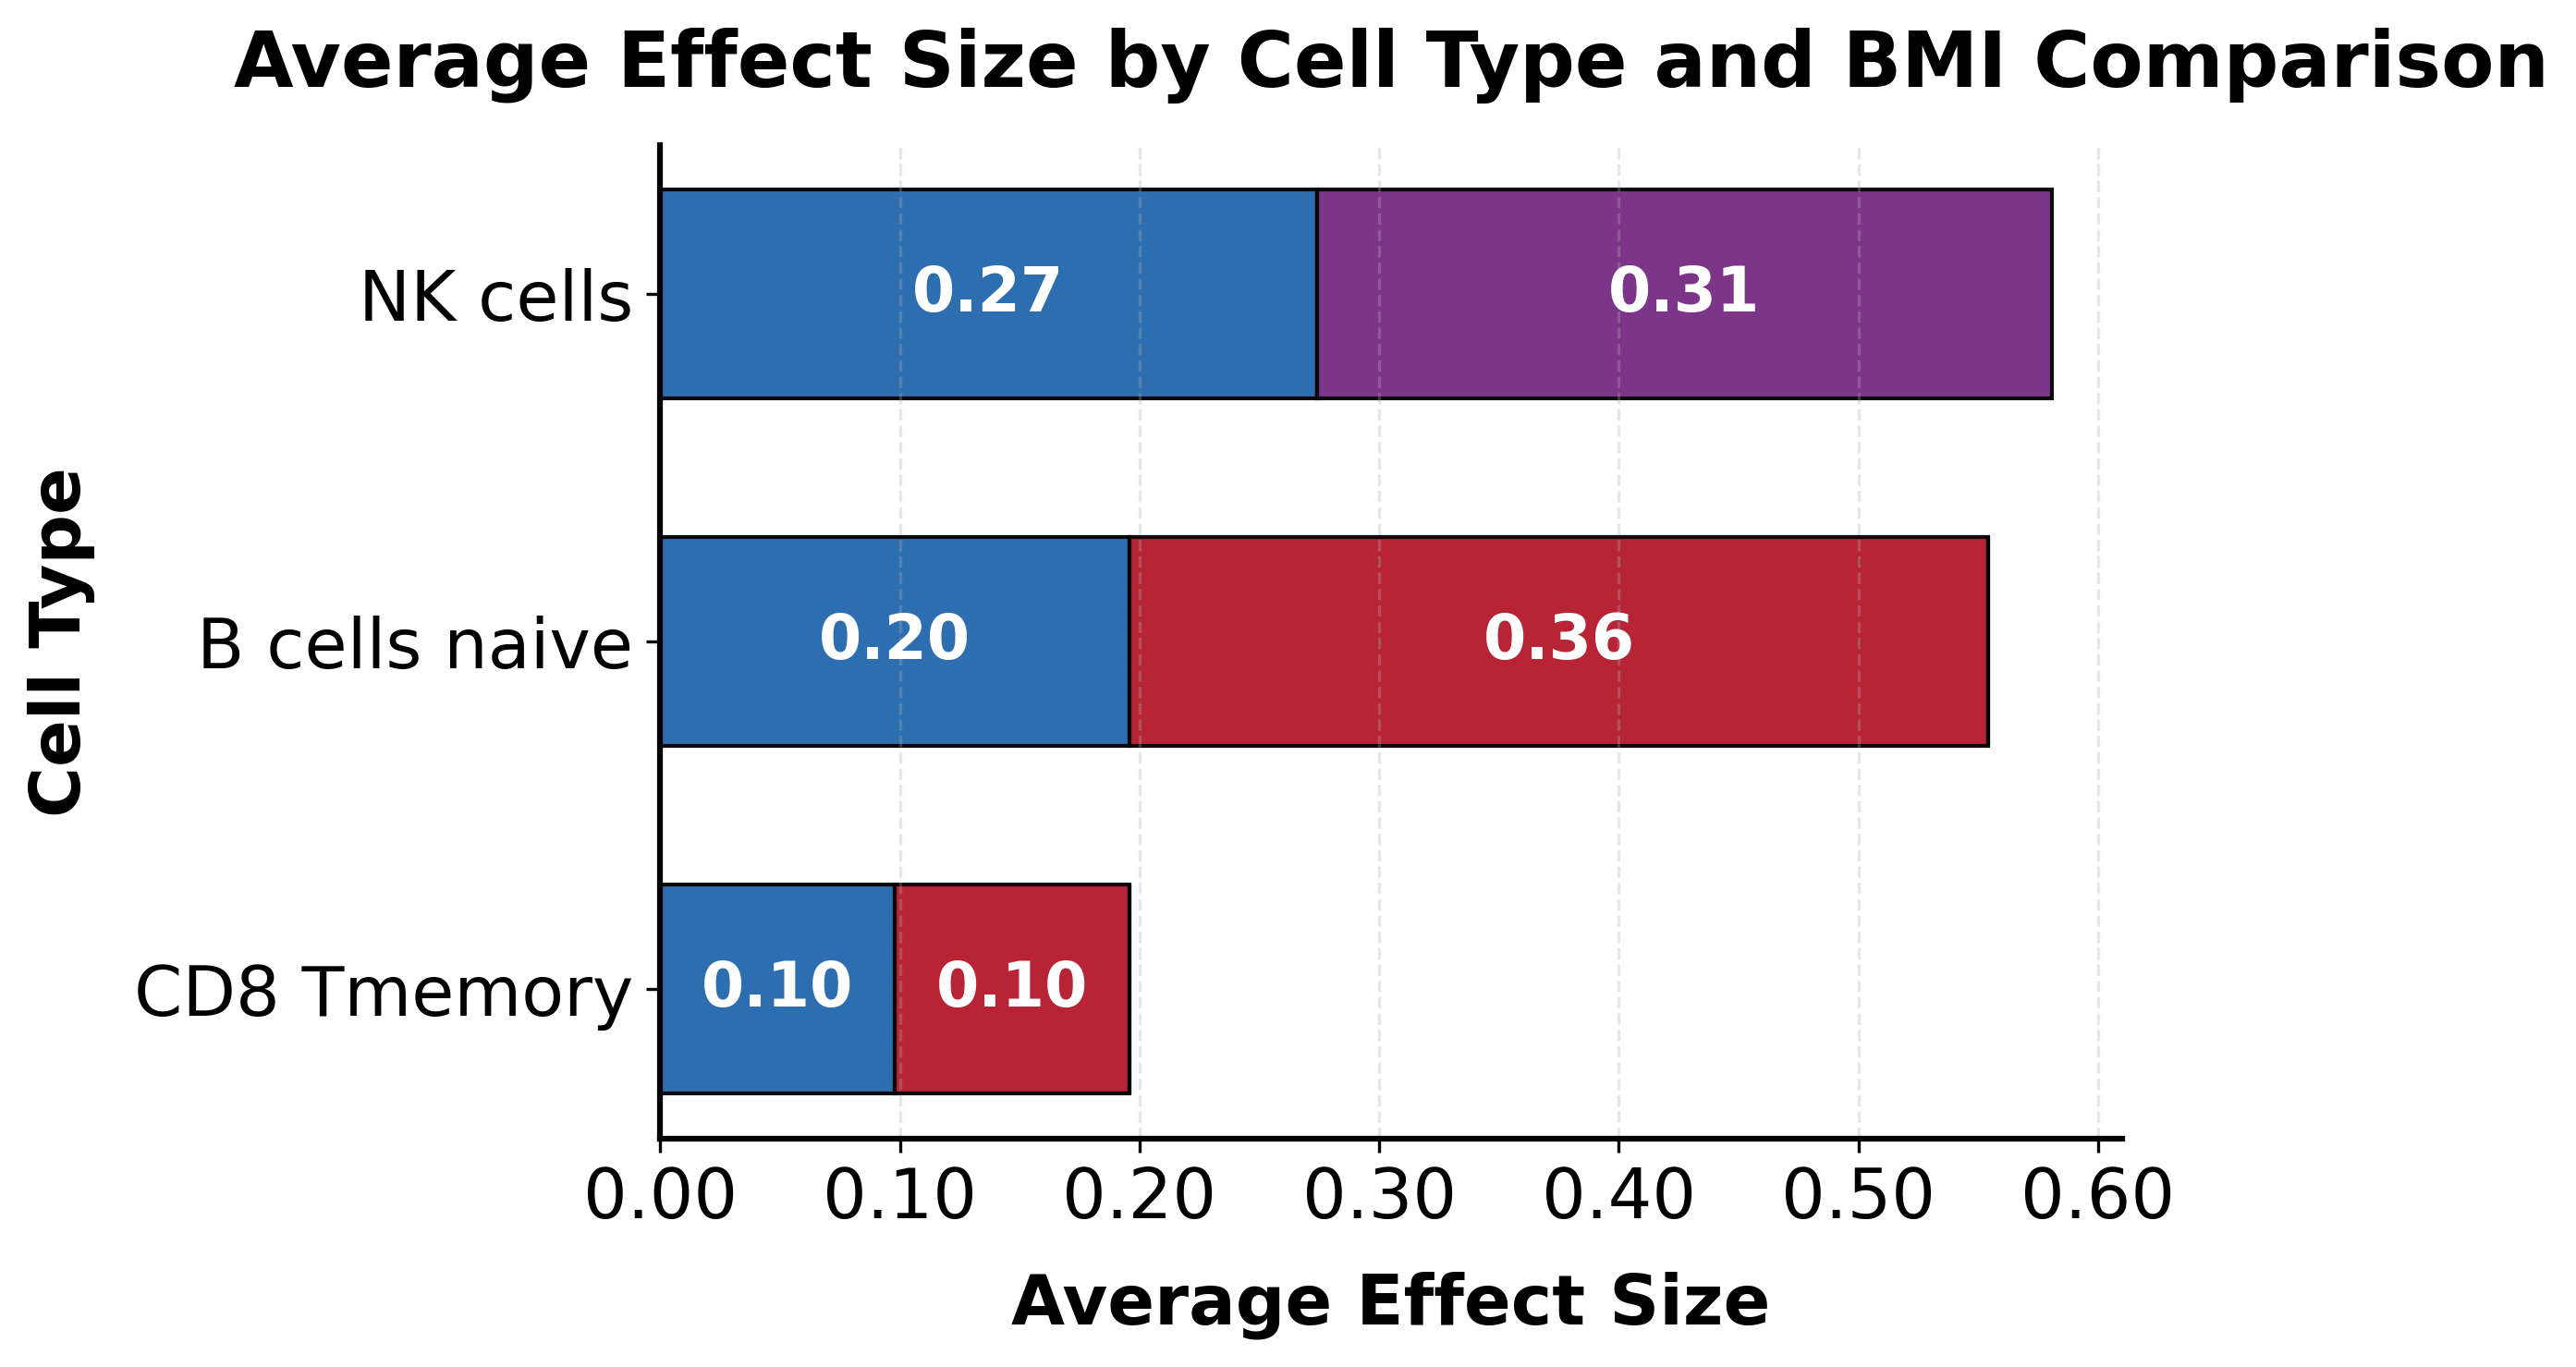


COMPARTMENT: Immune Coarse (immune_coarse)
  Whitelist size: 5; sample: ['Basophils', 'Dendritic cells', 'Monocytes', 'NK cells', 'T cells']
  [Immune Coarse] Applied whitelist: 5 cells — rows 130 -> 28
    [Immune Coarse] overweight: credible rows after whitelist = 8
    [Immune Coarse] obese: credible rows after whitelist = 0
    [Immune Coarse] obese_vs_overweight: credible rows after whitelist = 8
  Saved labels: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_immune_coarse/publication_figures/stacked_bar_plots/labels/cell_type_labels_count_hdi_Immune_Coarse.txt
  Saved data table: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_immune_coarse/publication_figures/stacked_bar_plots/data_tables/data_table_count_hdi_Immune_Coarse.csv
  ✅ Saved PNG: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_immune_coarse/publication_figures/stacked_bar_plots/stacked_bar_count_hdi_Immune_Coarse.png
  ✅ Saved SVG: /content/drive/MyDrive/ne

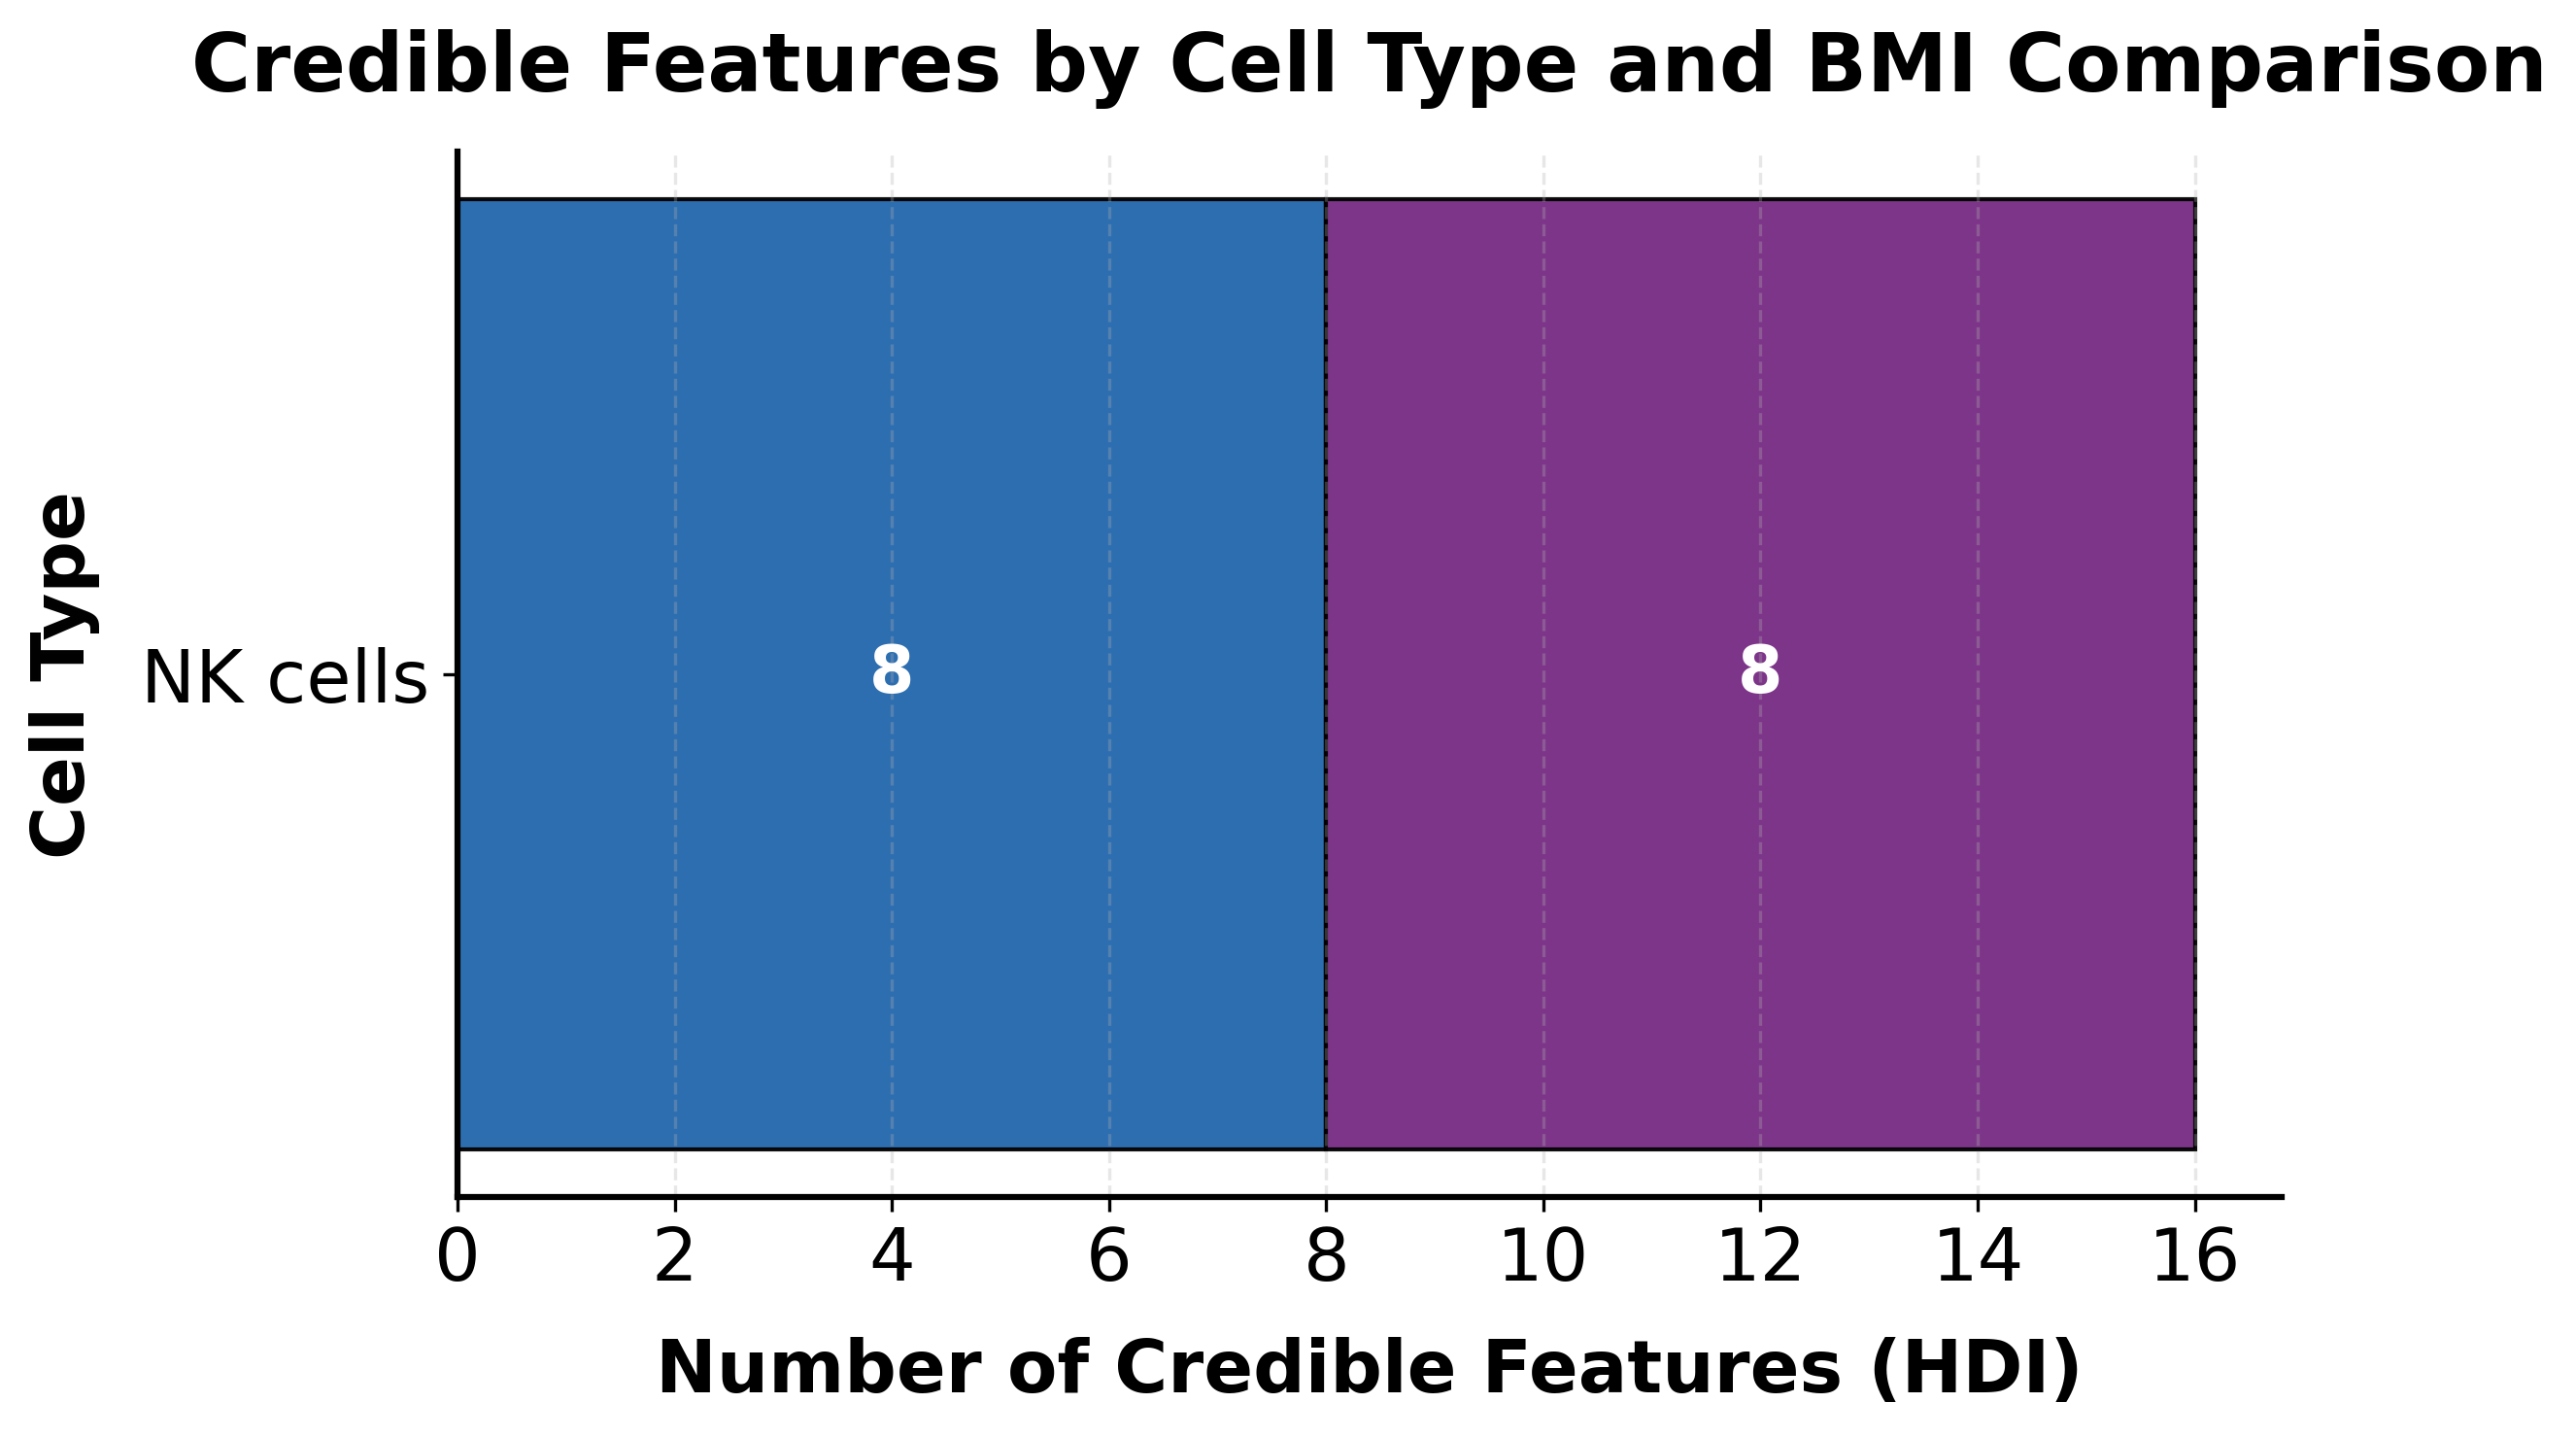

  [Immune Coarse] Applied whitelist: 5 cells — rows 130 -> 28
    [Immune Coarse] overweight: credible rows for effect size = 8
    [Immune Coarse] obese: credible rows for effect size = 0
    [Immune Coarse] obese_vs_overweight: credible rows for effect size = 8
  Saved labels: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_immune_coarse/publication_figures/stacked_bar_plots/labels/cell_type_labels_effect_size_Immune_Coarse.txt
  Saved data table: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_immune_coarse/publication_figures/stacked_bar_plots/data_tables/data_table_effect_size_Immune_Coarse.csv
  ✅ Saved PNG: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_immune_coarse/publication_figures/stacked_bar_plots/stacked_bar_effect_size_Immune_Coarse.png
  ✅ Saved SVG: /content/drive/MyDrive/new_dysfunction/svg_images/stacked_bar_plots/immune_coarse/stacked_bar_effect_size_Immune_Coarse.svg


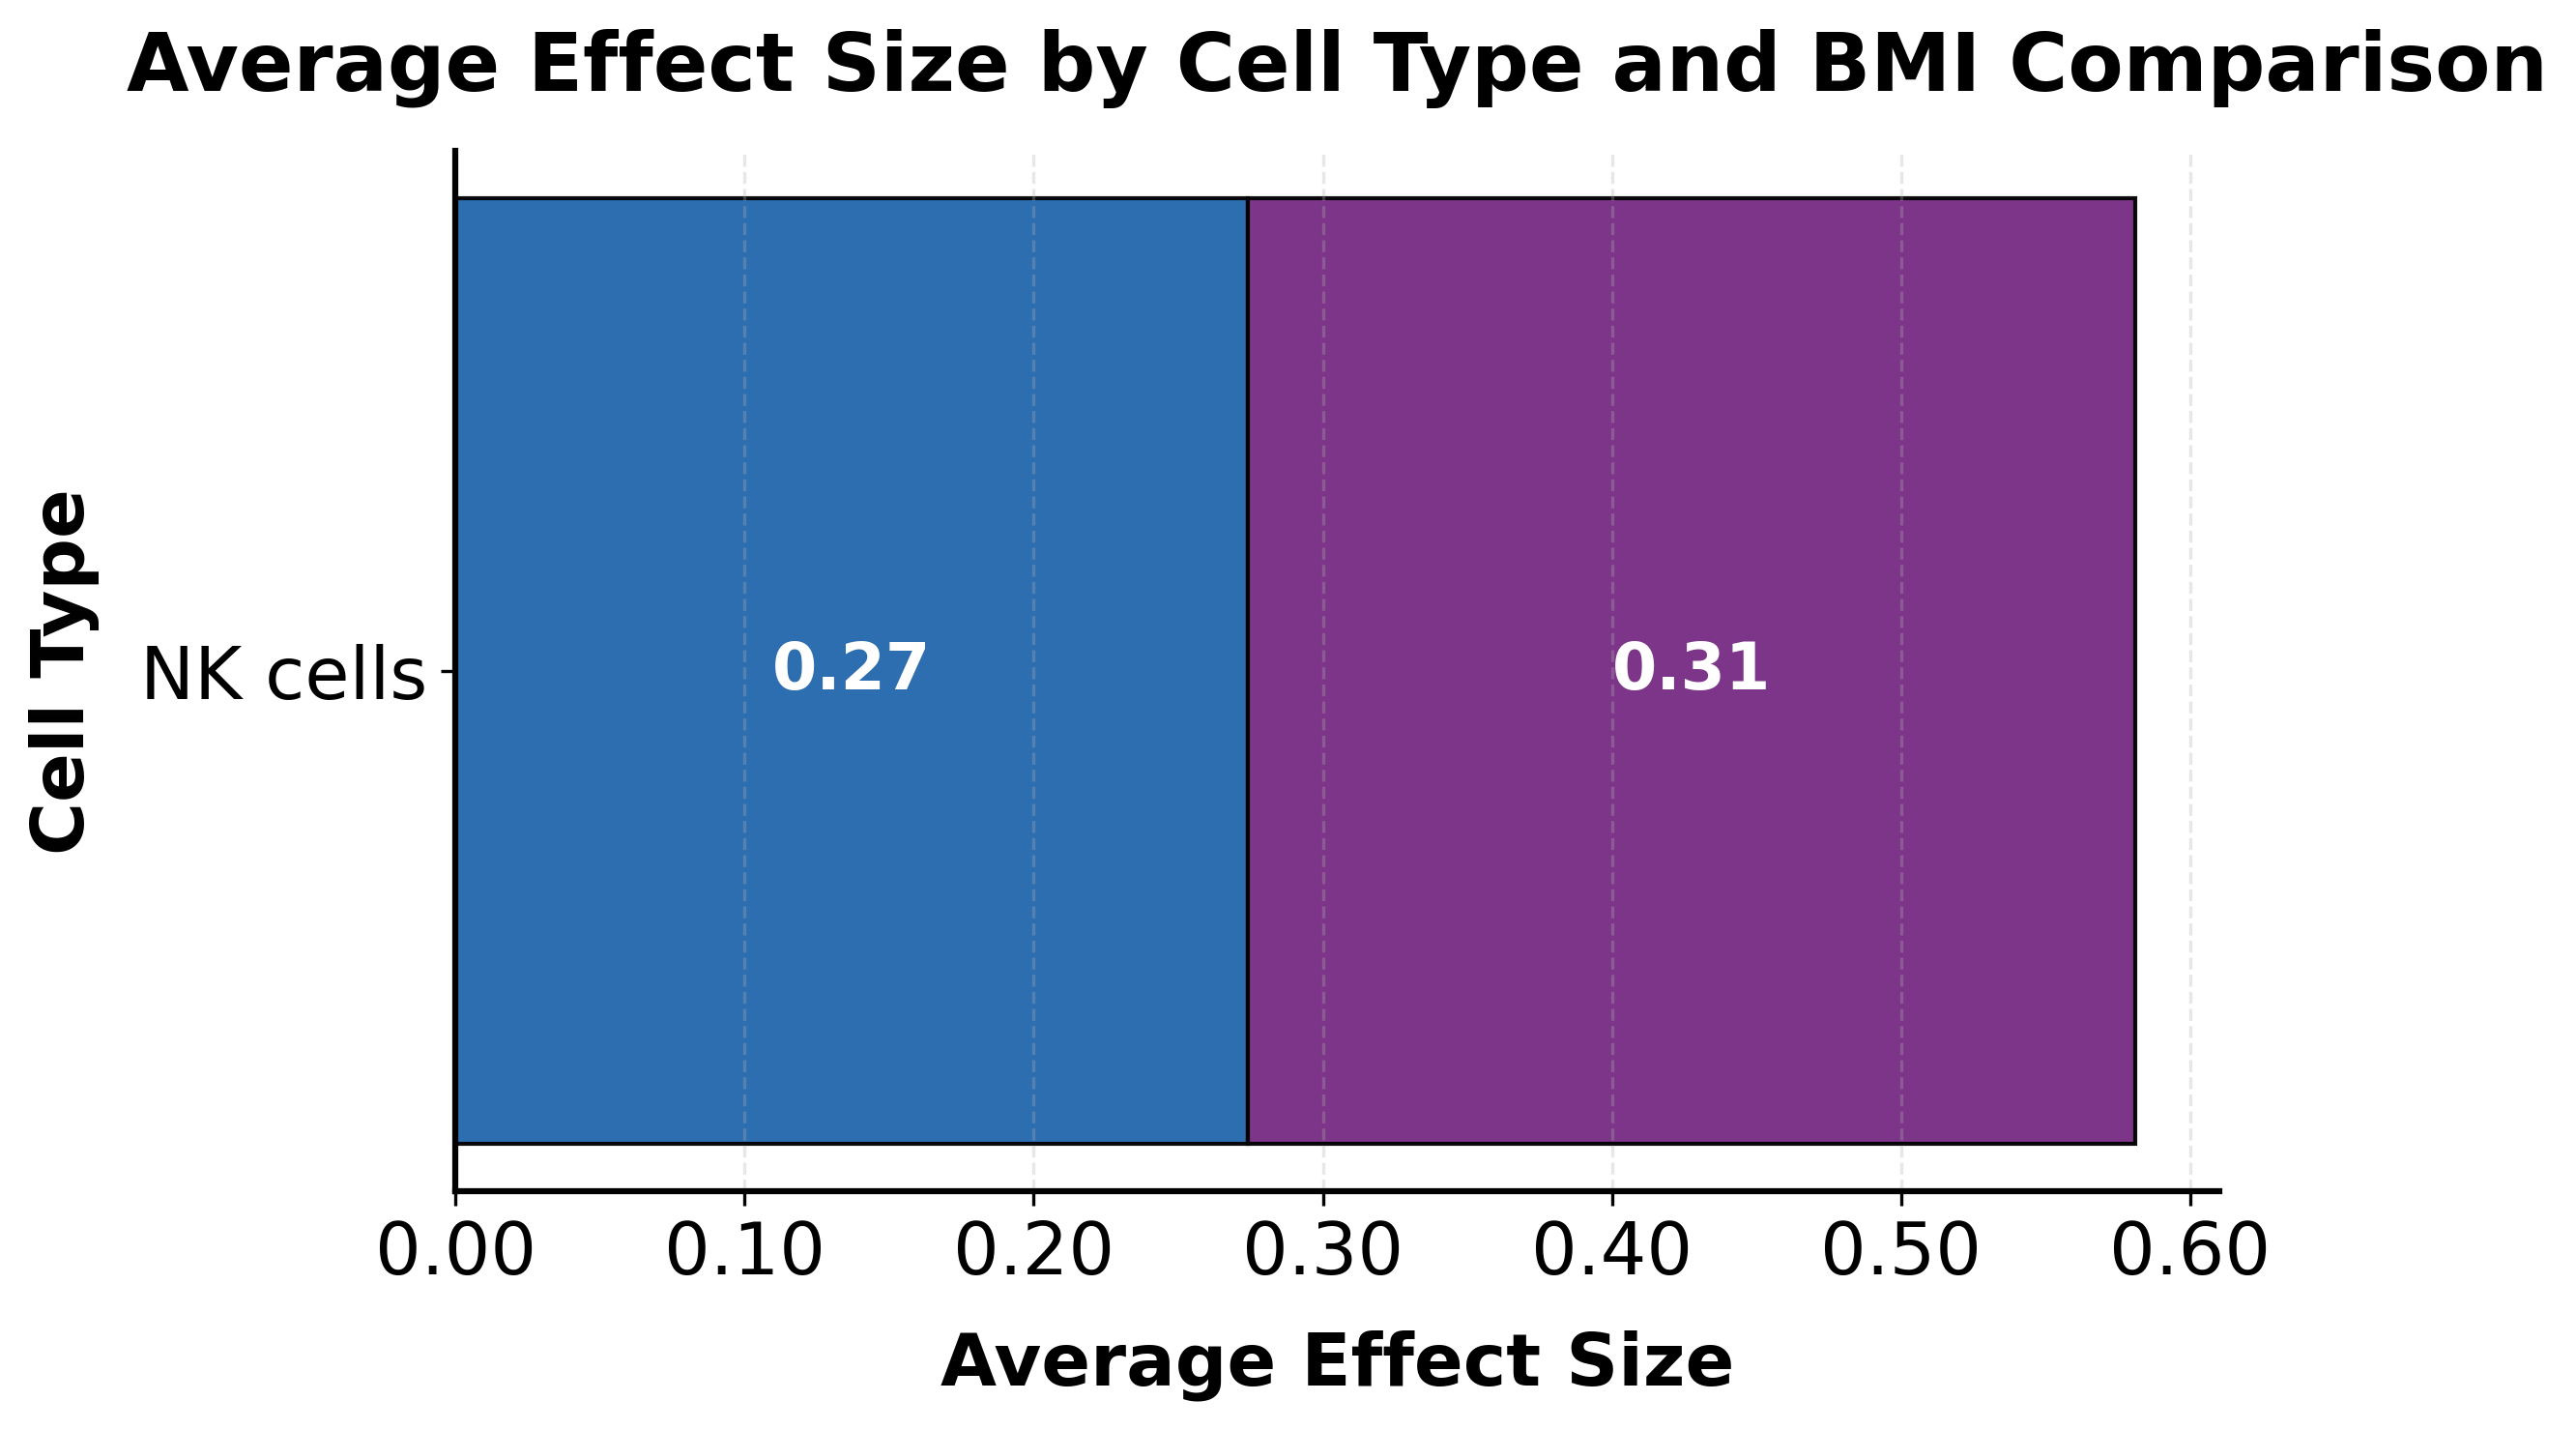


CREATING COMBINED PLOTS ACROSS ALL COMPARTMENTS
  [All_Compartments] No whitelist (empty) — using full master rows: 390
    [All_Compartments] overweight: credible rows after whitelist = 147
    [All_Compartments] obese: credible rows after whitelist = 48
    [All_Compartments] obese_vs_overweight: credible rows after whitelist = 33
  Saved labels: /content/drive/MyDrive/new_dysfunction/publication_figures/stacked_bar_plots/combined/labels/cell_type_labels_count_hdi_All_Compartments.txt
  Saved data table: /content/drive/MyDrive/new_dysfunction/publication_figures/stacked_bar_plots/combined/data_tables/data_table_count_hdi_All_Compartments.csv
  ✅ Saved PNG: /content/drive/MyDrive/new_dysfunction/publication_figures/stacked_bar_plots/combined/stacked_bar_count_hdi_All_Compartments.png
  ✅ Saved SVG: /content/drive/MyDrive/new_dysfunction/svg_images/stacked_bar_plots/combined/stacked_bar_count_hdi_All_Compartments.svg


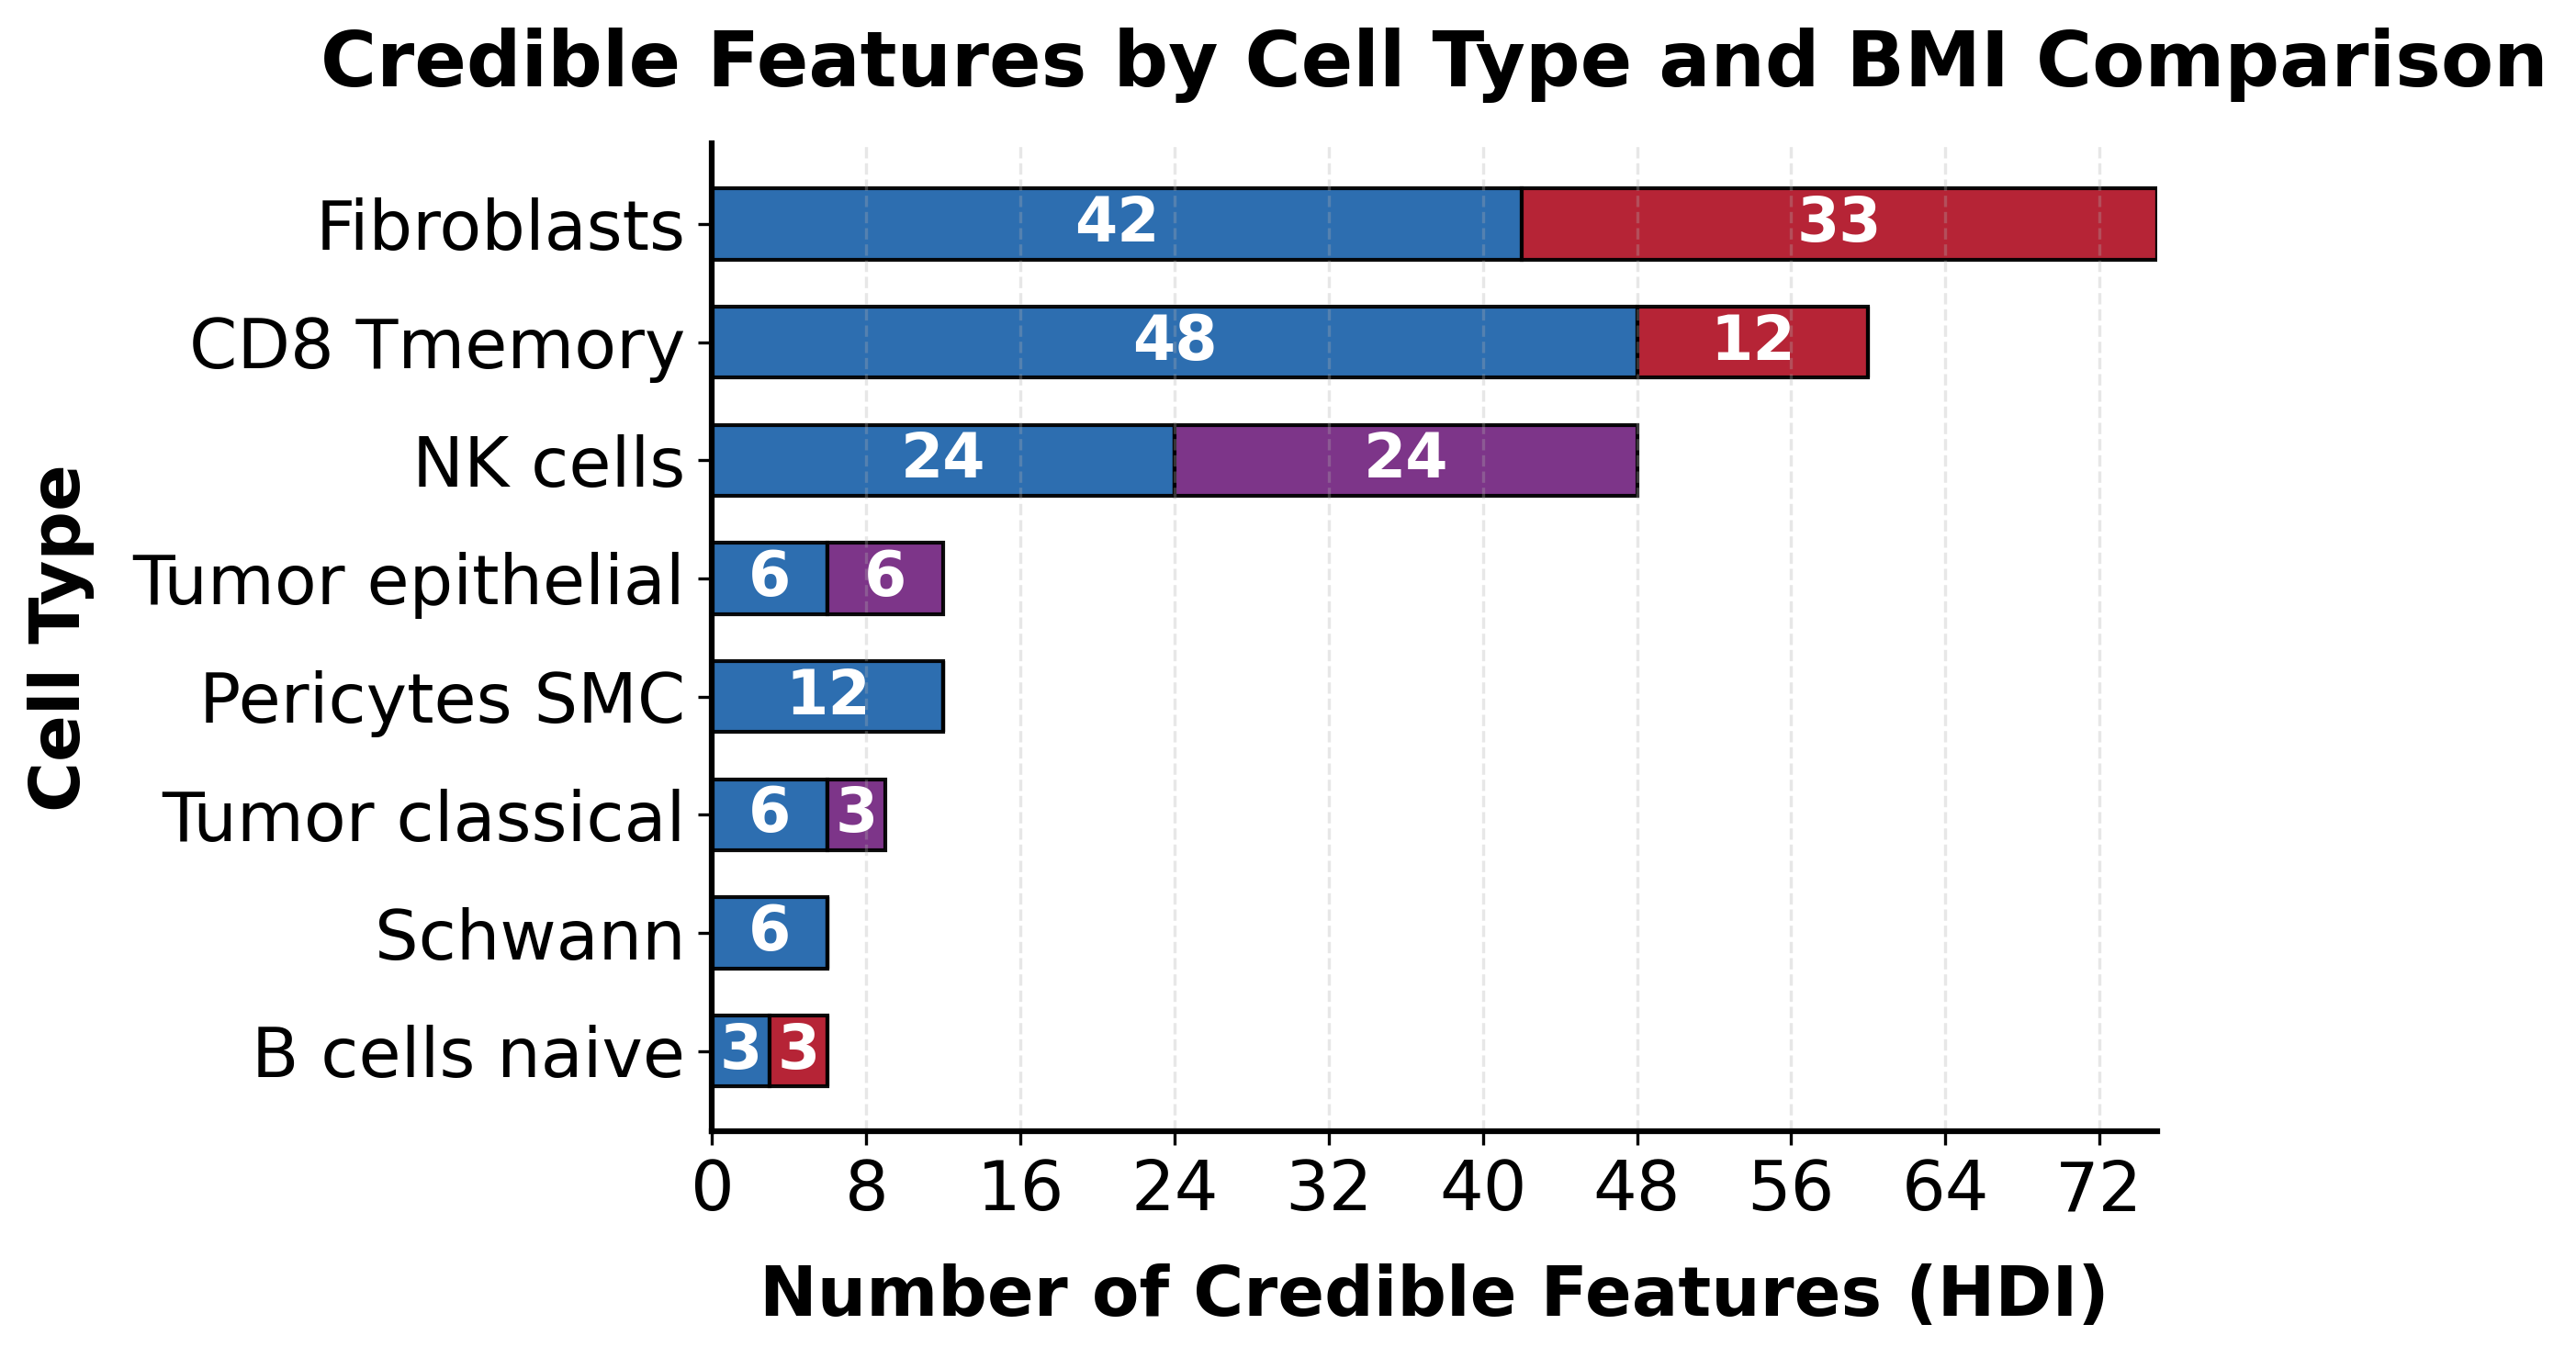

  [All_Compartments] No whitelist (empty) — using full master rows: 390
    [All_Compartments] overweight: credible rows for effect size = 147
    [All_Compartments] obese: credible rows for effect size = 48
    [All_Compartments] obese_vs_overweight: credible rows for effect size = 33
  Saved labels: /content/drive/MyDrive/new_dysfunction/publication_figures/stacked_bar_plots/combined/labels/cell_type_labels_effect_size_All_Compartments.txt
  Saved data table: /content/drive/MyDrive/new_dysfunction/publication_figures/stacked_bar_plots/combined/data_tables/data_table_effect_size_All_Compartments.csv
  ✅ Saved PNG: /content/drive/MyDrive/new_dysfunction/publication_figures/stacked_bar_plots/combined/stacked_bar_effect_size_All_Compartments.png
  ✅ Saved SVG: /content/drive/MyDrive/new_dysfunction/svg_images/stacked_bar_plots/combined/stacked_bar_effect_size_All_Compartments.svg


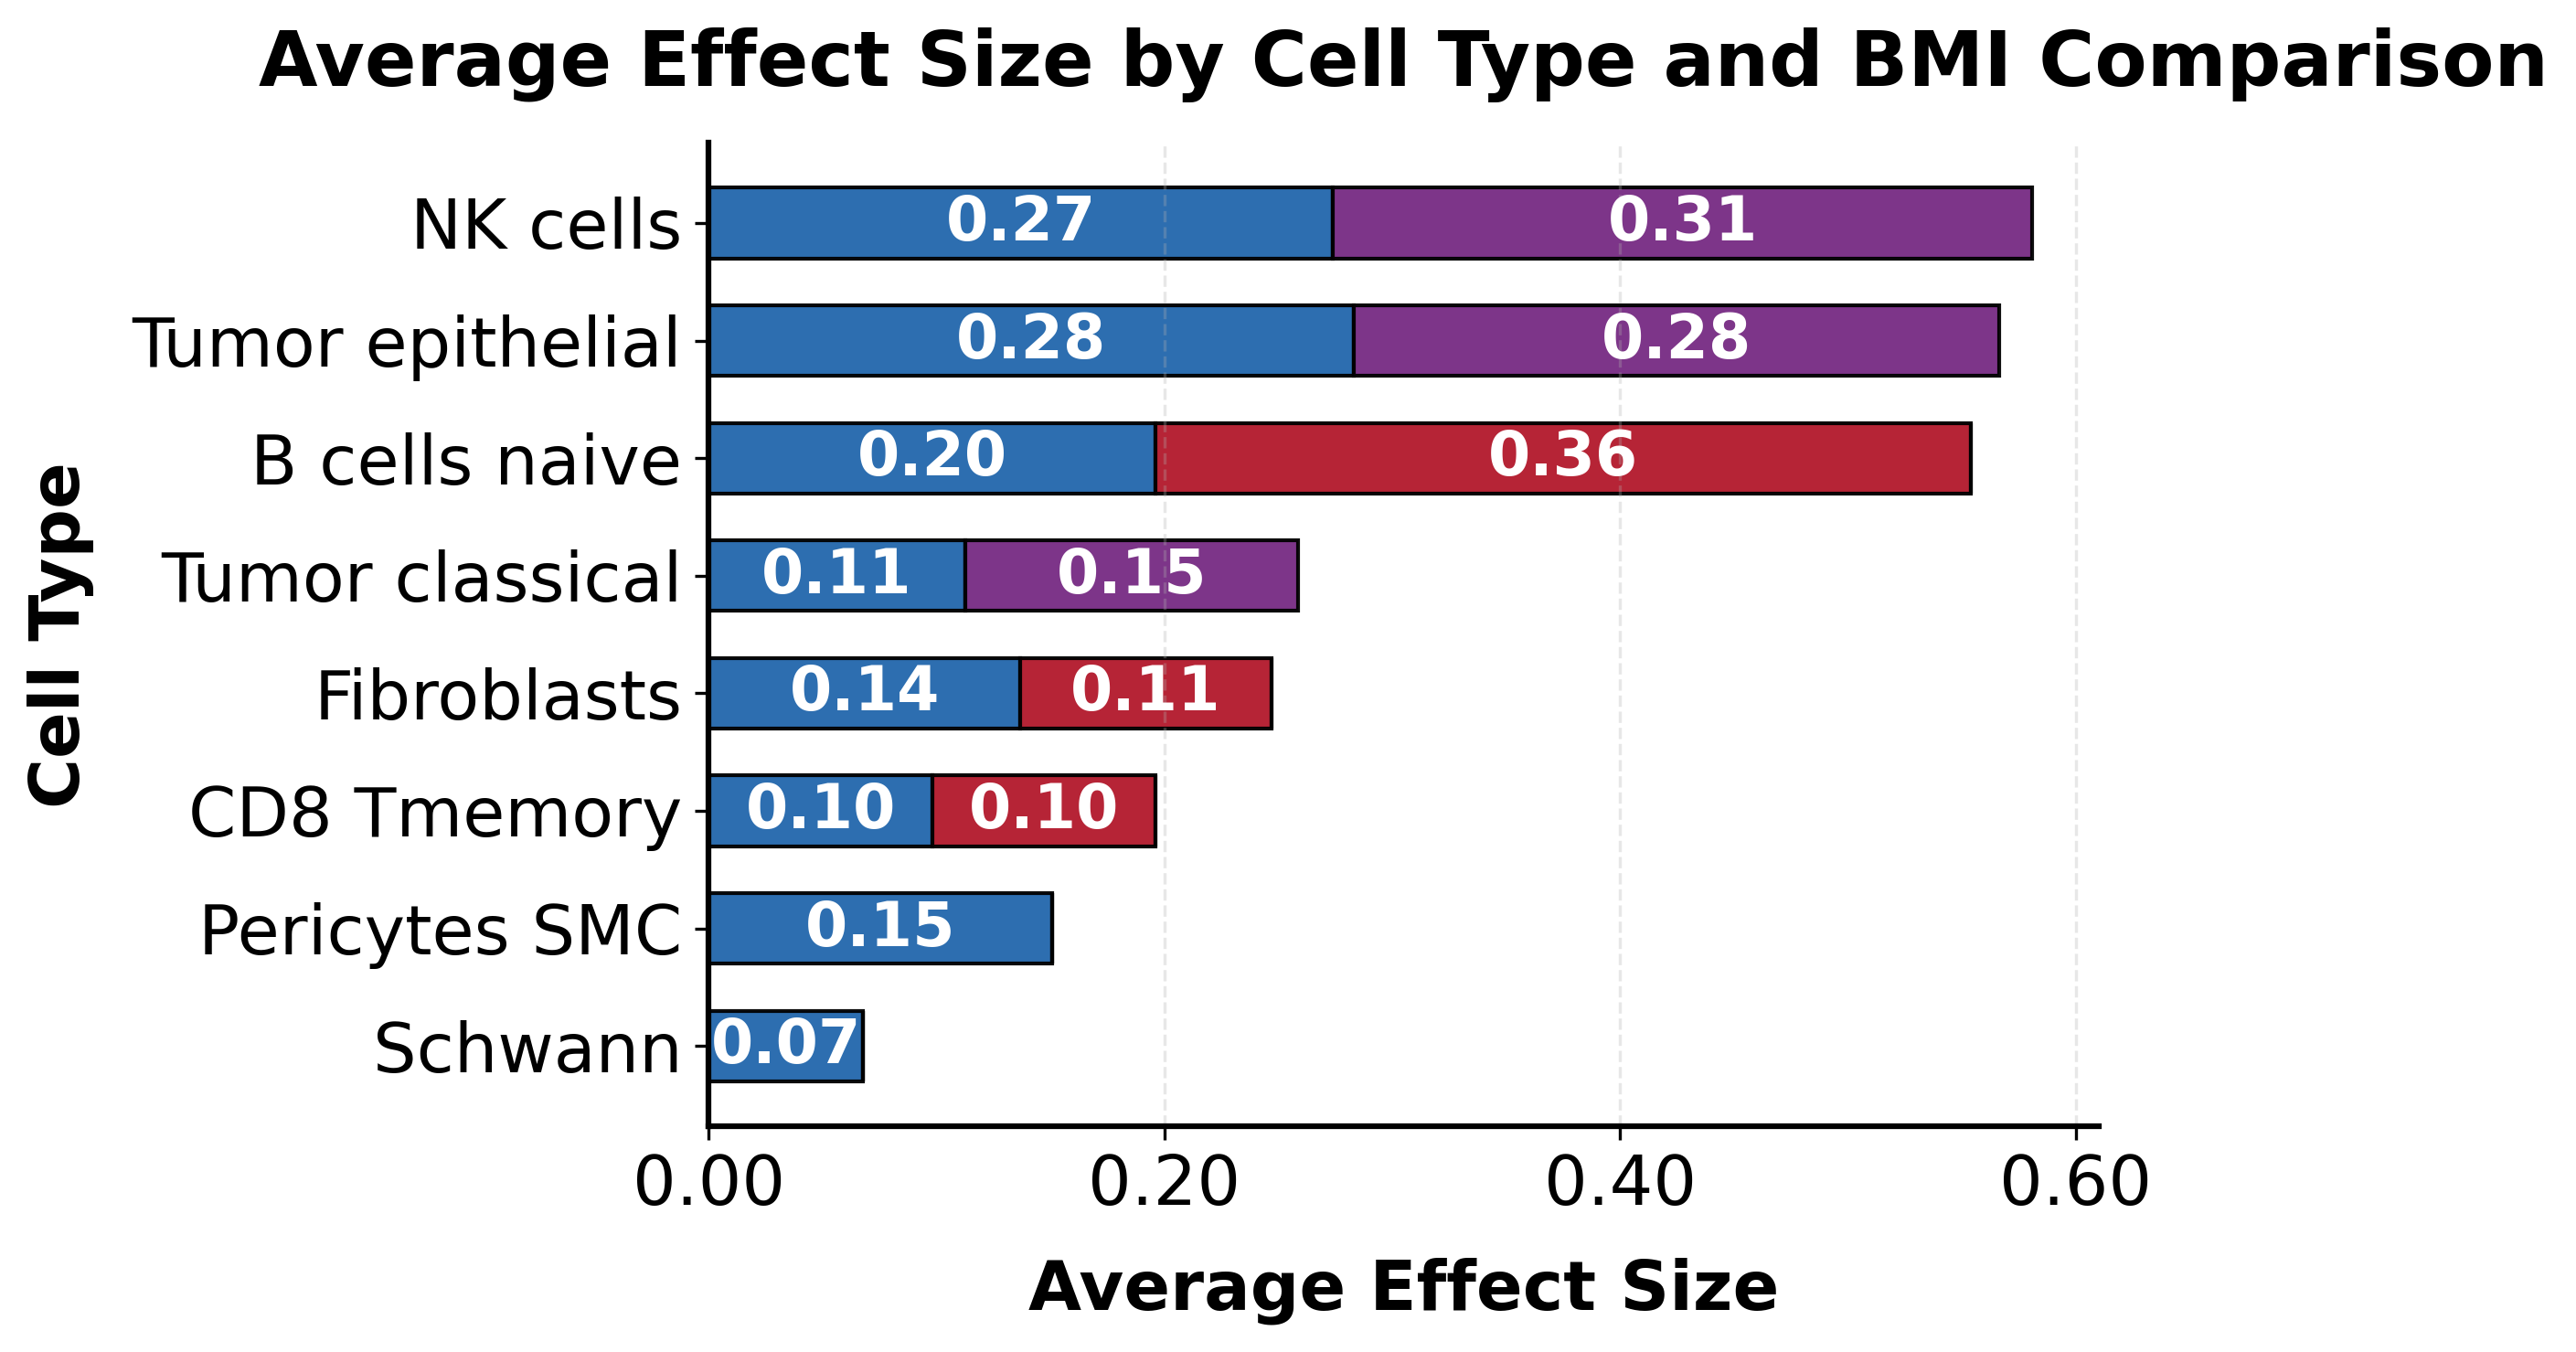


✅ ALL COMPARTMENTS COMPLETED

OUTPUT LOCATIONS:

Non-Immune:
  PNG: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_nonimmune/publication_figures/stacked_bar_plots
  SVG: /content/drive/MyDrive/new_dysfunction/svg_images/stacked_bar_plots/nonimmune

Immune Fine:
  PNG: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_immune_fine/publication_figures/stacked_bar_plots
  SVG: /content/drive/MyDrive/new_dysfunction/svg_images/stacked_bar_plots/immune_fine

Immune Coarse:
  PNG: /content/drive/MyDrive/new_dysfunction/bayesian_hierarchical_3group_immune_coarse/publication_figures/stacked_bar_plots
  SVG: /content/drive/MyDrive/new_dysfunction/svg_images/stacked_bar_plots/immune_coarse

Legend saved once at: /content/drive/MyDrive/new_dysfunction/svg_images/stacked_bar_plots/comparison_legend.svg and .png


In [ ]:
#!/usr/bin/env python3
"""
Compartment-whitelist counting using compartment-specific continuous directories
(uses each compartment's bayesian_results_3group_with_rope.csv as both data source
for that compartment and to build the whitelist; also builds a combined master from
all compartments). Legend is saved once (PNG + SVG) and not drawn on individual plots.
Axis formatting improved for clarity.
"""

import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker

warnings.filterwarnings("ignore")

# ============================================================================#
# CONFIGURATION & TUNABLES
# ============================================================================#

# ---------------- Path Configuration ----------------
BASE = "/content/drive/MyDrive/new_dysfunction"


COMPARTMENTS = {
    'nonimmune': {
        'dir': f"{BASE}/bayesian_hierarchical_3group_nonimmune",
        'name': 'Non-Immune'
    },
    'immune_fine': {
        'dir': f"{BASE}/bayesian_hierarchical_3group_immune_fine",
        'name': 'Immune Fine'
    },
    'immune_coarse': {
        'dir': f"{BASE}/bayesian_hierarchical_3group_immune_coarse",
        'name': 'Immune Coarse'
    }
}

# SVG output configuration (legend saved here once)
SVG_BASE = f"{BASE}/svg_images"
SVG_SUBFOLDER = "stacked_bar_plots"

# ---------------- Output Configuration ----------------
MAKE_COMBINED = True
SAVE_LABELS_SEPARATELY = True
SAVE_DATA_TABLE = True

# ---------------- Figure Dimensions & Aesthetics (unchanged) ----------------
FIGURE_WIDTH = 8
FIGURE_HEIGHT = 5
FIGURE_DPI = 300

BAR_HEIGHT = 0.6
BAR_SPACING = 0.4
BAR_ALPHA = 0.95
BAR_EDGE_LINEWIDTH = 1
BAR_EDGE_COLOR = 'black'

FONT_SIZE_BASE = 9
FONT_SIZE_TITLE = 20
FONT_SIZE_LABEL = 18
FONT_SIZE_TICK = 18
FONT_SIZE_BAR_TEXT = 16
FONT_SIZE_LEGEND = 16

AXES_LINEWIDTH = 1.5
GRID_ALPHA = 0.3
GRID_LINESTYLE = '--'
GRID_AXIS = 'x'

TITLE_PAD = 15
LABEL_PAD = 10
FIGURE_TIGHT_LAYOUT = True

COMPARISON_ORDER = ["overweight", "obese", "obese_vs_overweight"]

COMPARISON_LABELS = {
    "overweight": "Overweight vs Normal",
    "obese": "Obese vs Normal",
    "obese_vs_overweight": "Obese vs Overweight"
}

COMPARISON_COLORS = {
    "overweight": "#2166ac",
    "obese": "#b2182b",
    "obese_vs_overweight": "#762a83"
}

LEGEND_LOCATION = 'lower right'
LEGEND_FRAMEON = False
LEGEND_FANCYBOX = True
LEGEND_SHADOW = False
LEGEND_FRAMEALPHA = None

VALUE_LABEL_COLOR = 'white'
VALUE_LABEL_WEIGHT = 'bold'
VALUE_LABEL_HA = 'center'
VALUE_LABEL_VA = 'center'
EFFECT_SIZE_LABEL_THRESHOLD = 0.05
COUNT_LABEL_THRESHOLD = 0

SAVE_BBOX_INCHES = "tight"
SAVE_FORMAT = "png"

SHOW_TOP_SPINE = False
SHOW_RIGHT_SPINE = False
SHOW_LEFT_SPINE = True
SHOW_BOTTOM_SPINE = True

plt.rcParams.update({
    "figure.dpi": FIGURE_DPI,
    "savefig.dpi": FIGURE_DPI,
    "font.size": FONT_SIZE_BASE,
    "axes.titlesize": FONT_SIZE_TITLE,
    "axes.labelsize": FONT_SIZE_LABEL,
    "xtick.labelsize": FONT_SIZE_TICK,
    "ytick.labelsize": FONT_SIZE_TICK,
    "axes.linewidth": AXES_LINEWIDTH,
})

# ============================================================================#
# CELL TYPE CANONICALIZATION (unchanged)
# ============================================================================#
ALIASES = {
    "acinar": "Acinar", "adipocytes": "Adipocytes", "b cells": "B cells",
    "b cells naive": "B cells naive", "b naive": "B naive", "basophils": "Basophils",
    "cd4+ t cells": "CD4+ T cells", "cd4 t cells": "CD4+ T cells", "cd4 trm": "CD4 TRM",
    "cd4 t th1": "CD4 T Th1", "cd4 th1": "CD4 Th1", "cd4 t naive": "CD4 T naive",
    "cd4 tnaive": "CD4 Tnaive", "cd4 t regulatory": "CD4 T regulatory",
    "cd4 treg": "CD4 Treg", "cd4 tex": "CD4 Tex", "cd4 tfh": "CD4 Tfh",
    "cd4 th17": "CD4 Th17", "cd4 th2": "CD4 Th2", "cd4 th22": "CD4 Th22",
    "cd8+ t cells": "CD8+ T cells", "cd8 t cells": "CD8+ T cells",
    "cd8 stemlike": "CD8 stemlike", "cd8 trm": "CD8 TRM", "cd8 t effector": "CD8 T effector",
    "cd8 teffector": "CD8 Teffector", "cd8 t exhausted": "CD8 T exhausted",
    "cd8 tex": "CD8 Tex", "cd8 t general": "CD8 T general", "cd8 t naive": "CD8 T naive",
    "cd8 tnaive": "CD8 Tnaive", "cd8 tmemory": "CD8 Tmemory", "cd8 t memory": "CD8 T memory",
    "dendritic cells": "Dendritic cells", "pdc": "pDC", "mdc": "mDC", "cdc": "cDC",
    "endothelial": "Endothelial", "fibroblasts": "Fibroblasts", "caf": "CAF",
    "icaf": "iCAF", "mycaf": "myCAF", "apcaf": "apCAF", "islet endocrine": "Islet endocrine",
    "mait cells": "MAIT cells", "mdsc": "MDSC", "macrophages": "Macrophages",
    "mast": "Mast", "mast cells": "Mast cells", "monocytes": "Monocytes",
    "monocyte classical": "Monocyte classical", "monocytes classical": "Monocytes classical",
    "classical monocytes": "Classical monocytes", "monocyte non classical": "Monocyte non-classical",
    "myeloid cells": "Myeloid cells", "nk cells": "NK cells", "nkt cells": "NKT cells",
    "neural": "Neural", "neutrophils": "Neutrophils", "normal ductal": "Normal ductal",
    "pericytes smc": "Pericytes SMC", "plasma cells": "Plasma cells", "schwann": "Schwann",
    "stellate": "Stellate", "t cells": "T cells", "t cells general": "T cells general",
    "t gamma delta": "T gamma delta", "tam": "TAM", "tam c1qc": "TAM C1QC",
    "tam spp1": "TAM SPP1", "tumor basal": "Tumor basal", "tumor classical": "Tumor classical",
    "tumor epithelial": "Tumor epithelial", "tumor": "Tumor",
}

# ============================================================================#
# HELPERS (unchanged behavior, small improvements)
# ============================================================================#
def parse_feature(feature):
    if pd.isna(feature):
        return "Unknown", ""
    if "||" in str(feature):
        cell_type, signature = str(feature).split("||", 1)
        cell_type = cell_type.replace("_", " ")
        signature = re.sub(r"_Signature$", "", signature).replace("_", " ")
        return cell_type, signature
    return "Unknown", str(feature).replace("_", " ")

def canon_cell(cell_like):
    if pd.isna(cell_like):
        return cell_like
    s = str(cell_like).strip().lower()
    s = re.sub(r"[_\-]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    if s in ALIASES:
        return ALIASES[s]
    words = s.split()
    out = []
    for wl in words:
        w = wl.lower()
        if w in ['nk','tam','mhc','hla','tlr','il12','il','ifn','mdsc','mait','nkt','smc']:
            out.append(w.upper())
        elif w.startswith('cd') and len(w) > 2:
            out.append('CD'+w[2:])
        elif w in ['pdc','cdc','mdc']:
            out.append(w[0].upper() + 'DC')
        elif w.endswith('caf'):
            prefix = w[:-3]
            out.append((prefix if prefix else '') + 'CAF')
        elif w in ['trm','tex','tfh','tnaive','teffector','tmemory','treg']:
            out.append('T' + w[1:].capitalize() if len(w) > 1 else w.upper())
        elif w.startswith('th') and len(w) > 2 and w[2:].isdigit():
            out.append('Th' + w[2:])
        else:
            out.append(w.capitalize())
    res = ' '.join(out)
    res = re.sub(r'\bCD4 T\b', 'CD4+ T', res)
    res = re.sub(r'\bCD8 T\b', 'CD8+ T', res)
    if res.endswith(' cell'):
        res = res + 's'
    return res

def coerce_bool_series(s):
    s = s.fillna("").astype(str)
    num = pd.to_numeric(s, errors='coerce')
    return (num.fillna(0) != 0) | s.str.lower().isin(["true","t","yes"])

# ============================================================================#
# NORMALIZE CREDIBLE COLUMNS (robust) - unchanged
# ============================================================================#
def normalize_credible_columns(df):
    df = df.copy()
    df.columns = [str(c).strip().replace("\ufeff", "") for c in df.columns]
    col_lookup = {c.lower().strip(): c for c in df.columns}
    for comp in COMPARISON_ORDER:
        candidates = [f"{comp}_credible"]
        prob_candidates = [
            f"{comp}_prob_gt_0.2", f"{comp}_prob_gt_0.1",
            f"{comp}_prob_gt_0.3", f"{comp}_prob_positive",
            f"{comp}_prob_sig"
        ]
        chosen = None
        for cand in candidates:
            if cand.lower() in col_lookup:
                chosen = col_lookup[cand.lower()]
                break
        if chosen is None:
            for cand in prob_candidates:
                if cand.lower() in col_lookup:
                    chosen = col_lookup[cand.lower()]
                    break
        if chosen is None:
            for col in df.columns:
                lc = col.lower()
                if lc.startswith(comp) and ('prob' in lc or 'credible' in lc or 'sig' in lc):
                    chosen = col
                    break
        if chosen is None:
            df[f"{comp}_credible"] = False
            print(f"  Normalized {comp}: no source column found. Created {comp}_credible (all False).")
        else:
            df[f"{comp}_credible"] = coerce_bool_series(df[chosen])
            print(f"  Normalized {comp}: using '{chosen}' -> {comp}_credible (True: {int(df[f'{comp}_credible'].sum())})")
    return df

# ============================================================================#
# WHITELIST BUILDING (per-compartment)
# ============================================================================#
def build_compartment_whitelist(compartment_dir):
    csv_path = os.path.join(compartment_dir, "bayesian_results_3group_with_rope.csv")
    if not os.path.exists(csv_path):
        print("  Warning: compartment CSV not found:", csv_path)
        return set()
    df = pd.read_csv(csv_path, dtype=object)
    if 'cell_type' in df.columns and df['cell_type'].notna().any():
        parsed = df['cell_type'].astype(str).unique().tolist()
    else:
        parsed = df['feature'].astype(str).apply(lambda x: x.split("||")[0] if "||" in x else x).unique().tolist()
    canon = set([canon_cell(x) for x in parsed if pd.notna(x) and str(x).strip() != ''])
    canon = {c for c in canon if c not in [None,'nan','None','Unknown','']}
    return canon

# ============================================================================#
# PREPARE DATAFRAME WITH WHITELIST
# ============================================================================#
def prepare_dataframe_with_whitelist(df_master, whitelist, name_tag=""):
    df = df_master.copy()
    if 'cell_type' in df.columns and df['cell_type'].notna().any():
        df['cell_type_parsed'] = df['cell_type'].astype(str)
    else:
        df['cell_type_parsed'] = df['feature'].astype(str).apply(lambda x: x.split("||")[0] if "||" in x else x)
    df['cell_canon'] = df['cell_type_parsed'].apply(canon_cell)
    if whitelist:
        before = len(df)
        df = df[df['cell_canon'].isin(whitelist)].copy()
        after = len(df)
        print(f"  [{name_tag}] Applied whitelist: {len(whitelist)} cells — rows {before} -> {after}")
    else:
        print(f"  [{name_tag}] No whitelist (empty) — using full master rows: {len(df)}")
    df['cell_canon'] = df['cell_canon'].astype(str).replace(['nan','None','NoneType',''], np.nan)
    return df

# ============================================================================#
# AGGREGATION FUNCTIONS (counts & effect sizes) - unchanged logic
# ============================================================================#
def aggregate_credible_counts(df, name_tag=""):
    count_rows = []
    for comp in COMPARISON_ORDER:
        credible_col = f"{comp}_credible"
        if credible_col not in df.columns:
            print(f"    [{name_tag}] Warning: {credible_col} missing -> skipping counts for this comparison")
            continue
        credible = df[df[credible_col].astype(bool)].copy()
        print(f"    [{name_tag}] {comp}: credible rows after whitelist = {len(credible)}")
        if credible.empty:
            continue
        group = (credible.dropna(subset=['cell_canon']).groupby('cell_canon').size().rename('count').reset_index())
        for _, r in group.iterrows():
            count_rows.append({'cell_canon': r['cell_canon'], 'comparison': comp, 'count': int(r['count'])})
    return count_rows

def aggregate_effect_sizes(df, name_tag=""):
    effect_data = []
    for comp in COMPARISON_ORDER:
        mean_col = (f'{comp}_vs_normal_mean' if comp != 'obese_vs_overweight' else f'{comp}_mean')
        credible_col = f'{comp}_credible'
        if credible_col not in df.columns or mean_col not in df.columns:
            continue
        credible = df[df[credible_col].astype(bool)].copy()
        print(f"    [{name_tag}] {comp}: credible rows for effect size = {len(credible)}")
        if credible.empty:
            continue
        for ct in credible['cell_canon'].dropna().unique():
            ct_data = credible[credible['cell_canon'] == ct]
            mean_vals = pd.to_numeric(ct_data[mean_col], errors='coerce').abs().dropna()
            mean_effect = float(mean_vals.mean()) if len(mean_vals) > 0 else 0.0
            effect_data.append({'cell_canon': ct, 'comparison': comp, 'mean_abs_effect': mean_effect})
    return effect_data

def create_pivot_table(data_rows, value_column, sort_by_total=True):
    if not data_rows:
        return None
    summary = pd.DataFrame(data_rows)
    pivot = summary.pivot(index='cell_canon', columns='comparison', values=value_column).fillna(0)
    for comp in COMPARISON_ORDER:
        if comp not in pivot.columns:
            pivot[comp] = 0
    pivot = pivot[COMPARISON_ORDER]
    if sort_by_total:
        pivot['total'] = pivot.sum(axis=1)
        pivot = pivot.sort_values('total', ascending=True).drop('total', axis=1)
    return pivot

# ============================================================================#
# LABEL / LEGEND SAVE FUNCTIONS
# ============================================================================#
def save_labels_to_file(pivot, out_base, name_tag, plot_type):
    if not SAVE_LABELS_SEPARATELY:
        return
    labels_dir = os.path.join(out_base, "labels")
    os.makedirs(labels_dir, exist_ok=True)
    filename = os.path.join(labels_dir, f"cell_type_labels_{plot_type}_{name_tag.replace(' ', '_')}.txt")
    with open(filename, 'w') as f:
        f.write(f"Cell Type Labels for {name_tag} - {plot_type}\n")
        f.write("=" * 60 + "\n\n")
        f.write("Display Order (Bottom to Top):\n")
        f.write("-" * 60 + "\n")
        for idx, cell_type in enumerate(pivot.index, 1):
            f.write(f"{idx:2d}. {cell_type}\n")
        f.write("\n")
        f.write(f"Total cell types: {len(pivot.index)}\n")
    print(f"  Saved labels: {filename}")

def save_comparison_legend_to_file_once(svg_out_base):
    """
    Save a single legend (PNG + SVG) for all comparisons.
    Will overwrite if exists.
    """
    os.makedirs(svg_out_base, exist_ok=True)
    legend_path_png = os.path.join(svg_out_base, "comparison_legend.png")
    legend_path_svg = os.path.join(svg_out_base, "comparison_legend.svg")

    patches = [mpatches.Patch(facecolor=COMPARISON_COLORS[k], edgecolor='black', label=COMPARISON_LABELS[k]) for k in COMPARISON_ORDER]

    fig_legend = plt.figure(figsize=(6,2), dpi=FIGURE_DPI)
    ax = fig_legend.add_subplot(111)
    ax.axis('off')
    leg = ax.legend(handles=patches, loc='center', frameon=False, ncol=1, fontsize=FONT_SIZE_LEGEND)
    for lh in leg.get_lines():
        lh.set_linewidth(4)
    fig_legend.savefig(legend_path_png, bbox_inches='tight', dpi=FIGURE_DPI, facecolor='white')
    fig_legend.savefig(legend_path_svg, format='svg', bbox_inches='tight')
    plt.close(fig_legend)
    print(f"  Saved legend PNG: {legend_path_png}")
    print(f"  Saved legend SVG: {legend_path_svg}")

def save_data_table_to_csv(pivot, out_base, name_tag, plot_type):
    if not SAVE_DATA_TABLE:
        return
    tables_dir = os.path.join(out_base, "data_tables")
    os.makedirs(tables_dir, exist_ok=True)
    filename = os.path.join(tables_dir, f"data_table_{plot_type}_{name_tag.replace(' ', '_')}.csv")
    output_df = pivot.copy()
    output_df.columns = [COMPARISON_LABELS[col] for col in output_df.columns]
    output_df.index.name = 'Cell Type'
    output_df.to_csv(filename)
    print(f"  Saved data table: {filename}")

# ============================================================================#
# PLOTTING UTILITIES (no legend drawn on plots; legend saved separately)
# ============================================================================#
def setup_figure():
    fig, ax = plt.subplots(figsize=(FIGURE_WIDTH, FIGURE_HEIGHT), dpi=FIGURE_DPI)
    return fig, ax

def plot_stacked_bars(ax, pivot, show_values=True, value_formatter=lambda x: f'{int(x)}', value_threshold=0):
    y = np.arange(len(pivot.index))
    left = np.zeros(len(pivot))
    for comp in COMPARISON_ORDER:
        values = pivot[comp].values
        ax.barh(y, values, BAR_HEIGHT,
               label=COMPARISON_LABELS[comp],
               left=left,
               color=COMPARISON_COLORS[comp],
               alpha=BAR_ALPHA,
               edgecolor=BAR_EDGE_COLOR,
               linewidth=BAR_EDGE_LINEWIDTH)
        if show_values:
            for i, (val, lft) in enumerate(zip(values, left)):
                if val > value_threshold:
                    ax.text(lft + val / 2, i, value_formatter(val),
                           ha=VALUE_LABEL_HA,
                           va=VALUE_LABEL_VA,
                           fontsize=FONT_SIZE_BAR_TEXT,
                           fontweight=VALUE_LABEL_WEIGHT,
                           color=VALUE_LABEL_COLOR)
        left += values
    return ax

def style_axes(ax, ylabel, xlabel, title, yticklabels, is_count=False):
    ax.set_ylabel(ylabel, fontsize=FONT_SIZE_LABEL, fontweight='bold', labelpad=LABEL_PAD)
    ax.set_xlabel(xlabel, fontsize=FONT_SIZE_LABEL, fontweight='bold', labelpad=LABEL_PAD)
    if title:
        ax.set_title(title, fontsize=FONT_SIZE_TITLE, fontweight='bold', pad=TITLE_PAD)
    ax.set_yticks(np.arange(len(yticklabels)))
    ax.set_yticklabels(yticklabels, fontsize=FONT_SIZE_TICK)
    # DO NOT draw legend on plot (we save legend once separately)
    # Configure spines
    ax.spines['top'].set_visible(SHOW_TOP_SPINE)
    ax.spines['right'].set_visible(SHOW_RIGHT_SPINE)
    ax.spines['left'].set_visible(SHOW_LEFT_SPINE)
    ax.spines['bottom'].set_visible(SHOW_BOTTOM_SPINE)
    # Configure grid
    ax.grid(axis=GRID_AXIS, alpha=GRID_ALPHA, linestyle=GRID_LINESTYLE)
    # Axis formatting: counts -> integer ticks; effect sizes -> 2 decimal places
    if is_count:
        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    else:
        ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

def save_and_show_figure(fig, filepath, svg_filepath=None):
    if FIGURE_TIGHT_LAYOUT:
        plt.tight_layout()
    os.makedirs(os.path.dirname(filepath), exist_ok=True)
    plt.savefig(filepath, dpi=FIGURE_DPI, bbox_inches=SAVE_BBOX_INCHES, format=SAVE_FORMAT)
    print(f"  Saved PNG: {filepath}")
    if svg_filepath:
        os.makedirs(os.path.dirname(svg_filepath), exist_ok=True)
        plt.savefig(svg_filepath, format='svg', bbox_inches=SAVE_BBOX_INCHES)
        print(f" Saved SVG: {svg_filepath}")
    plt.show()
    plt.close(fig)

# ============================================================================#
# CREATE PLOTS (counts & effect sizes) - use whitelist to filter master rows
# ============================================================================#
def create_stacked_bar_count_whitelist(df_master, whitelist, out_base, svg_out_base, name_tag=""):
    df = prepare_dataframe_with_whitelist(df_master, whitelist, name_tag)
    count_rows = aggregate_credible_counts(df, name_tag)
    if not count_rows:
        print(f"  No credible features found for {name_tag}")
        return
    pivot = create_pivot_table(count_rows, 'count', sort_by_total=True)
    save_labels_to_file(pivot, out_base, name_tag, "count_hdi")
    save_data_table_to_csv(pivot, out_base, name_tag, "count_hdi")
    fig, ax = setup_figure()
    plot_stacked_bars(ax, pivot, show_values=True, value_formatter=lambda x: f'{int(x)}', value_threshold=COUNT_LABEL_THRESHOLD)
    style_axes(ax, ylabel='Cell Type', xlabel='Number of Credible Features (HDI)', title='Credible Features by Cell Type and BMI Comparison', yticklabels=pivot.index, is_count=True)
    filename = os.path.join(out_base, f"stacked_bar_count_hdi_{name_tag.replace(' ', '_')}.png")
    svg_filename = os.path.join(svg_out_base, f"stacked_bar_count_hdi_{name_tag.replace(' ', '_')}.svg")
    save_and_show_figure(fig, filename, svg_filename)

def create_stacked_bar_effect_size_whitelist(df_master, whitelist, out_base, svg_out_base, name_tag=""):
    df = prepare_dataframe_with_whitelist(df_master, whitelist, name_tag)
    effect_data = aggregate_effect_sizes(df, name_tag)
    if not effect_data:
        print(f"  No credible features for effect size for {name_tag}")
        return
    pivot = create_pivot_table(effect_data, 'mean_abs_effect', sort_by_total=True)
    save_labels_to_file(pivot, out_base, name_tag, "effect_size")
    save_data_table_to_csv(pivot, out_base, name_tag, "effect_size")
    fig, ax = setup_figure()
    plot_stacked_bars(ax, pivot, show_values=True, value_formatter=lambda x: f'{x:.2f}', value_threshold=EFFECT_SIZE_LABEL_THRESHOLD)
    style_axes(ax, ylabel='Cell Type', xlabel='Average Effect Size', title='Average Effect Size by Cell Type and BMI Comparison', yticklabels=pivot.index, is_count=False)
    filename = os.path.join(out_base, f"stacked_bar_effect_size_{name_tag.replace(' ', '_')}.png")
    svg_filename = os.path.join(svg_out_base, f"stacked_bar_effect_size_{name_tag.replace(' ', '_')}.svg")
    save_and_show_figure(fig, filename, svg_filename)

# ============================================================================#
# MAIN EXECUTION
# ============================================================================#
def main():
    print("="*80)
    print("STACKED BAR PLOTS - CREDIBLE FEATURE COUNTS (COMPARTMENT-WHITELIST MODE)")
    print("="*80)

    # Build combined master from all compartment CSVs (use each compartment's ROPE file)
    master_rows = []
    for comp_key, info in COMPARTMENTS.items():
        comp_dir = info['dir']
        rope_csv = os.path.join(comp_dir, "bayesian_results_3group_with_rope.csv")
        if not os.path.exists(rope_csv):
            print(f"  Compartment ROPE file not found (skipping): {rope_csv}")
            continue
        print(f"  Loading compartment ROPE for master: {rope_csv} ({comp_key})")
        dfc = pd.read_csv(rope_csv, dtype=object)
        master_rows.append(dfc)
    if not master_rows:
        raise FileNotFoundError("No compartment ROPE CSVs found to build master. Check COMPARTMENTS paths.")
    master = pd.concat(master_rows, ignore_index=True)
    print(f"Master assembled: {len(master)} rows from {len(master_rows)} compartment files")

    # Normalize credible/prob columns on master (robust)
    master = normalize_credible_columns(master)

    # Ensure SVG folder exists and save legend once
    svg_out_base_all = os.path.join(SVG_BASE, SVG_SUBFOLDER)
    save_comparison_legend_to_file_once(svg_out_base_all)

    # Process each compartment individually (build whitelist from the compartment-specific CSV)
    combined_rows_for_combined = []
    for comp_key, info in COMPARTMENTS.items():
        comp_dir = info['dir']
        comp_name = info['name']
        print("\n" + "="*70)
        print(f"COMPARTMENT: {comp_name} ({comp_key})")
        whitelist = build_compartment_whitelist(comp_dir)
        print(f"  Whitelist size: {len(whitelist)}; sample: {sorted(list(whitelist))[:8]}")
        out_base = os.path.join(comp_dir, "publication_figures", "stacked_bar_plots")
        svg_out_base = os.path.join(SVG_BASE, SVG_SUBFOLDER, comp_key)
        os.makedirs(out_base, exist_ok=True)
        os.makedirs(svg_out_base, exist_ok=True)
        create_stacked_bar_count_whitelist(master, whitelist, out_base, svg_out_base, name_tag=comp_name)
        create_stacked_bar_effect_size_whitelist(master, whitelist, out_base, svg_out_base, name_tag=comp_name)
        tmp = master.copy()
        tmp['_compartment'] = comp_key
        combined_rows_for_combined.append(tmp)

    # OPTIONAL: combined across compartments (no whitelist)
    if MAKE_COMBINED and combined_rows_for_combined:
        combined_df = pd.concat(combined_rows_for_combined, ignore_index=True)
        combined_out = os.path.join(BASE, "publication_figures", "stacked_bar_plots", "combined")
        svg_combined_out = os.path.join(SVG_BASE, SVG_SUBFOLDER, "combined")
        os.makedirs(combined_out, exist_ok=True)
        os.makedirs(svg_combined_out, exist_ok=True)
        print("\n" + "="*70)
        print("CREATING COMBINED PLOTS ACROSS ALL COMPARTMENTS")
        create_stacked_bar_count_whitelist(combined_df, whitelist=set(), out_base=combined_out, svg_out_base=svg_combined_out, name_tag="All_Compartments")
        create_stacked_bar_effect_size_whitelist(combined_df, whitelist=set(), out_base=combined_out, svg_out_base=svg_combined_out, name_tag="All_Compartments")

    print("\n" + "="*80)
    print("ALL COMPARTMENTS COMPLETED")
    print("="*80)

    # Print output locations
    print("\nOUTPUT LOCATIONS:")
    for comp_key, info in COMPARTMENTS.items():
        comp_dir = info['dir']
        png_dir = os.path.join(comp_dir, "publication_figures", "stacked_bar_plots")
        svg_dir = os.path.join(SVG_BASE, SVG_SUBFOLDER, comp_key)
        print(f"\n{info['name']}:")
        print(f"  PNG: {png_dir}")
        print(f"  SVG: {svg_dir}")
    print(f"\nLegend saved once at: {svg_out_base_all}/comparison_legend.svg and .png")

if __name__ == "__main__":
    main()
